In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

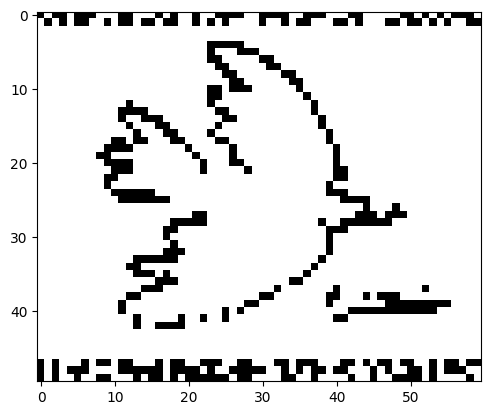

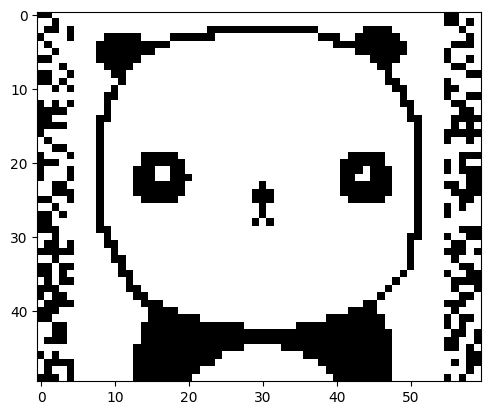

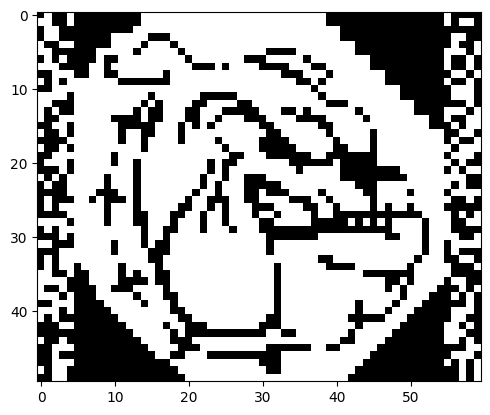

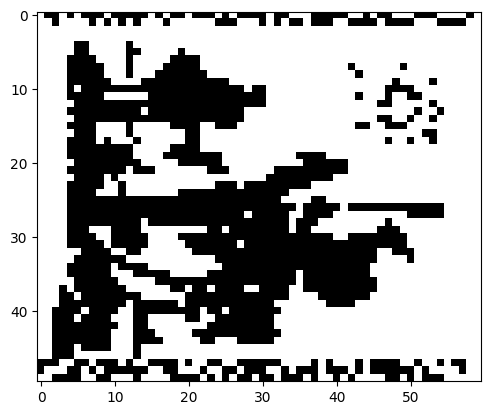

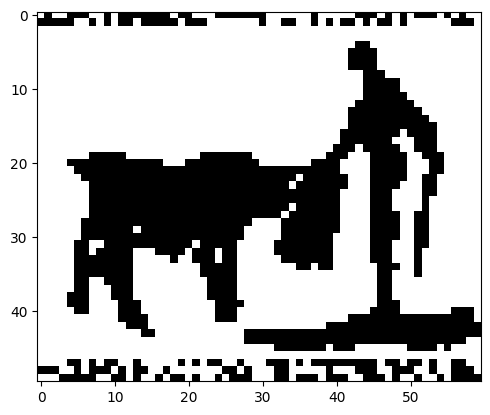

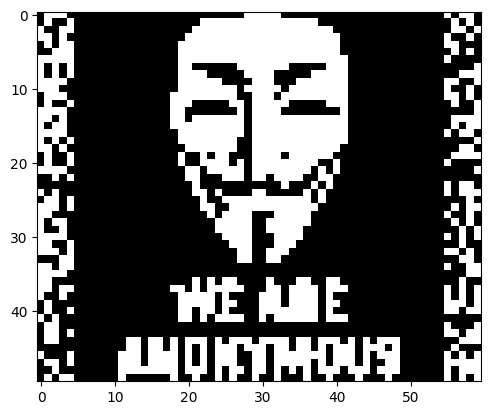

In [ ]:

def train_hopfield(list_X, width_max, height_max):
    N = width_max * height_max
    W = np.zeros((N, N))
    eta = 1
    for X in list_X:
        X = np.array(X)
        X_flat = np.copy(X.flatten())


        Delta_W = eta * np.outer(X_flat,X_flat)

        np.fill_diagonal(Delta_W, 0)
        W += Delta_W
    return W

def test_hopfield(W, X_init, max_iterations=150):
    X = np.copy(X_init.flatten())
    iteration =0
    update = True
    while (iteration < max_iterations) and (update == True):
        update = False

        # Se permutan los indices
        permuted_indices = np.random.permutation(len(X))

        for i in permuted_indices:
          h = np.dot(W[i, :], X)
          output = sign_function(h)
          if X[i] != output:
            X[i] = output
            update = True

        iteration+=1
    print("test finished after " + str(iteration) + " iterations")
    return X

def sign_function(h):
  if(h>=0):return 1
  else: return -1

def check_w(W):
  # Set of allowed values of w
  allowed_values = {0, 1, -1}

  result = np.isin(W, list(allowed_values)).all()

  print("W allowed values: " + str(result) )
  print("W symmetric: "+str(np.array_equal(W, W.T)))


def create_dataset_from_images(images, padding="white"):
  width_max = 0
  height_max = 0

  dataset_train = []
  for image in images:
      img = Image.open(image)
      width, height = img.size
      if width > width_max: width_max = width
      if height > height_max: height_max = height

  for image in images:
      img = Image.open(image)
      img = np.array(img)
      img = 2 * img - 1 #transformar False,True a -1,1

      if padding == "white": padded_img = pad_with_white(img,width_max,height_max)
      if padding == "noise": padded_img = pad_with_noise(img,width_max,height_max)
      if padding == "none": padded_img = img

      dataset_train.append(padded_img)
  return dataset_train, width_max,height_max

def create_datasets_from_sorting_images(images):
  dataset_train_45 = []
  dataset_train_50  = []

  for image in images:
    img = Image.open(image)
    img = np.array(img)
    # Transform values from 0,1 to -1,1
    img = 2 * img - 1
    if len(img) == 45:
      dataset_train_45.append(img) #all images with 45 pixels height
    elif len(img) == 50:
      dataset_train_50.append(img)


  return dataset_train_45,dataset_train_50




def create_random_padding(pad_size):
    return np.random.choice([-1, 1], size=pad_size, p =[0.5,0.5])

def pad_with_white(img,width_max,height_max):
    height, width = img.shape
    width_pad = (width_max - width) //2
    height_pad = (height_max - height) //2
    padded_img = np.pad(
        img,
        ((height_pad, height_max - height - height_pad), (width_pad, width_max - width - width_pad)),
        mode='constant',
        constant_values=1
    )
    return padded_img
def pad_with_noise(img,width_max,height_max):
    height, width = img.shape
    width_pad = (width_max - width)
    height_pad = (height_max - height)

    # Create random padding for top, bottom, left, and right
    top_padding = create_random_padding((height_pad // 2, width_max))
    bottom_padding = create_random_padding((height_pad - height_pad // 2, width_max))
    left_padding = create_random_padding((height, width_pad // 2))
    right_padding = create_random_padding((height, width_pad - width_pad // 2))

    # Add padding (random) around the image to center it
    padded_img = np.vstack([top_padding, img, bottom_padding]) if height_pad > 0 else img
    padded_img = np.hstack([left_padding, padded_img, right_padding]) if width_pad > 0 else padded_img

    return padded_img




images = ["paloma.bmp", "panda.bmp", "perro.bmp", "quijote.bmp", "torero.bmp", "v.bmp"]

dataset_train_noise, width_max,height_max = create_dataset_from_images(images, "noise")
dataset_train_white, width_max,height_max = create_dataset_from_images(images, "white")

dataset_train_45, dataset_train_50 = create_datasets_from_sorting_images(images)


for image in dataset_train_noise:
  plt.imshow(image, cmap='gray')
  plt.show()

W allowed values: True
W symmetric: True
W allowed values: True
W symmetric: True
W allowed values: True
W symmetric: True
W allowed values: True
W symmetric: True
W allowed values: True
W symmetric: True
W allowed values: True
W symmetric: True


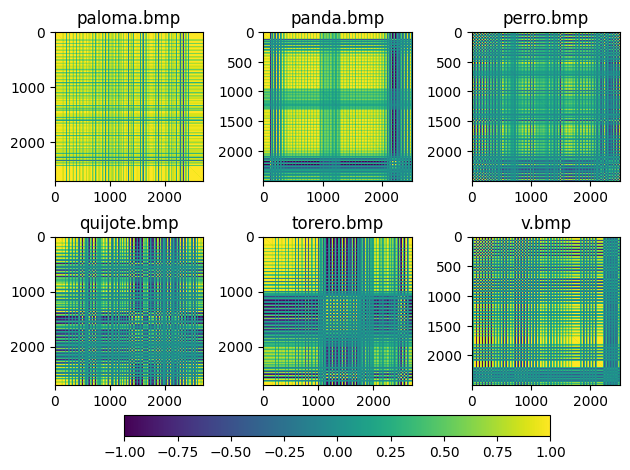

In [ ]:
dataset_train, width_max,height_max = create_dataset_from_images(images, "none")
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3)
fig.figsize=(20, 10)
axes = [ax1,ax2,ax3,ax4,ax5,ax6]
i=0
for image in dataset_train:
  W = train_hopfield([image], width_max = image.shape[1], height_max= image.shape[0])
  check_w(W)
  im =axes[i].imshow(W)

  axes[i].set_title(str(images[i]))
  i+=1


fig.tight_layout()
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.07)
fig.show()

test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations


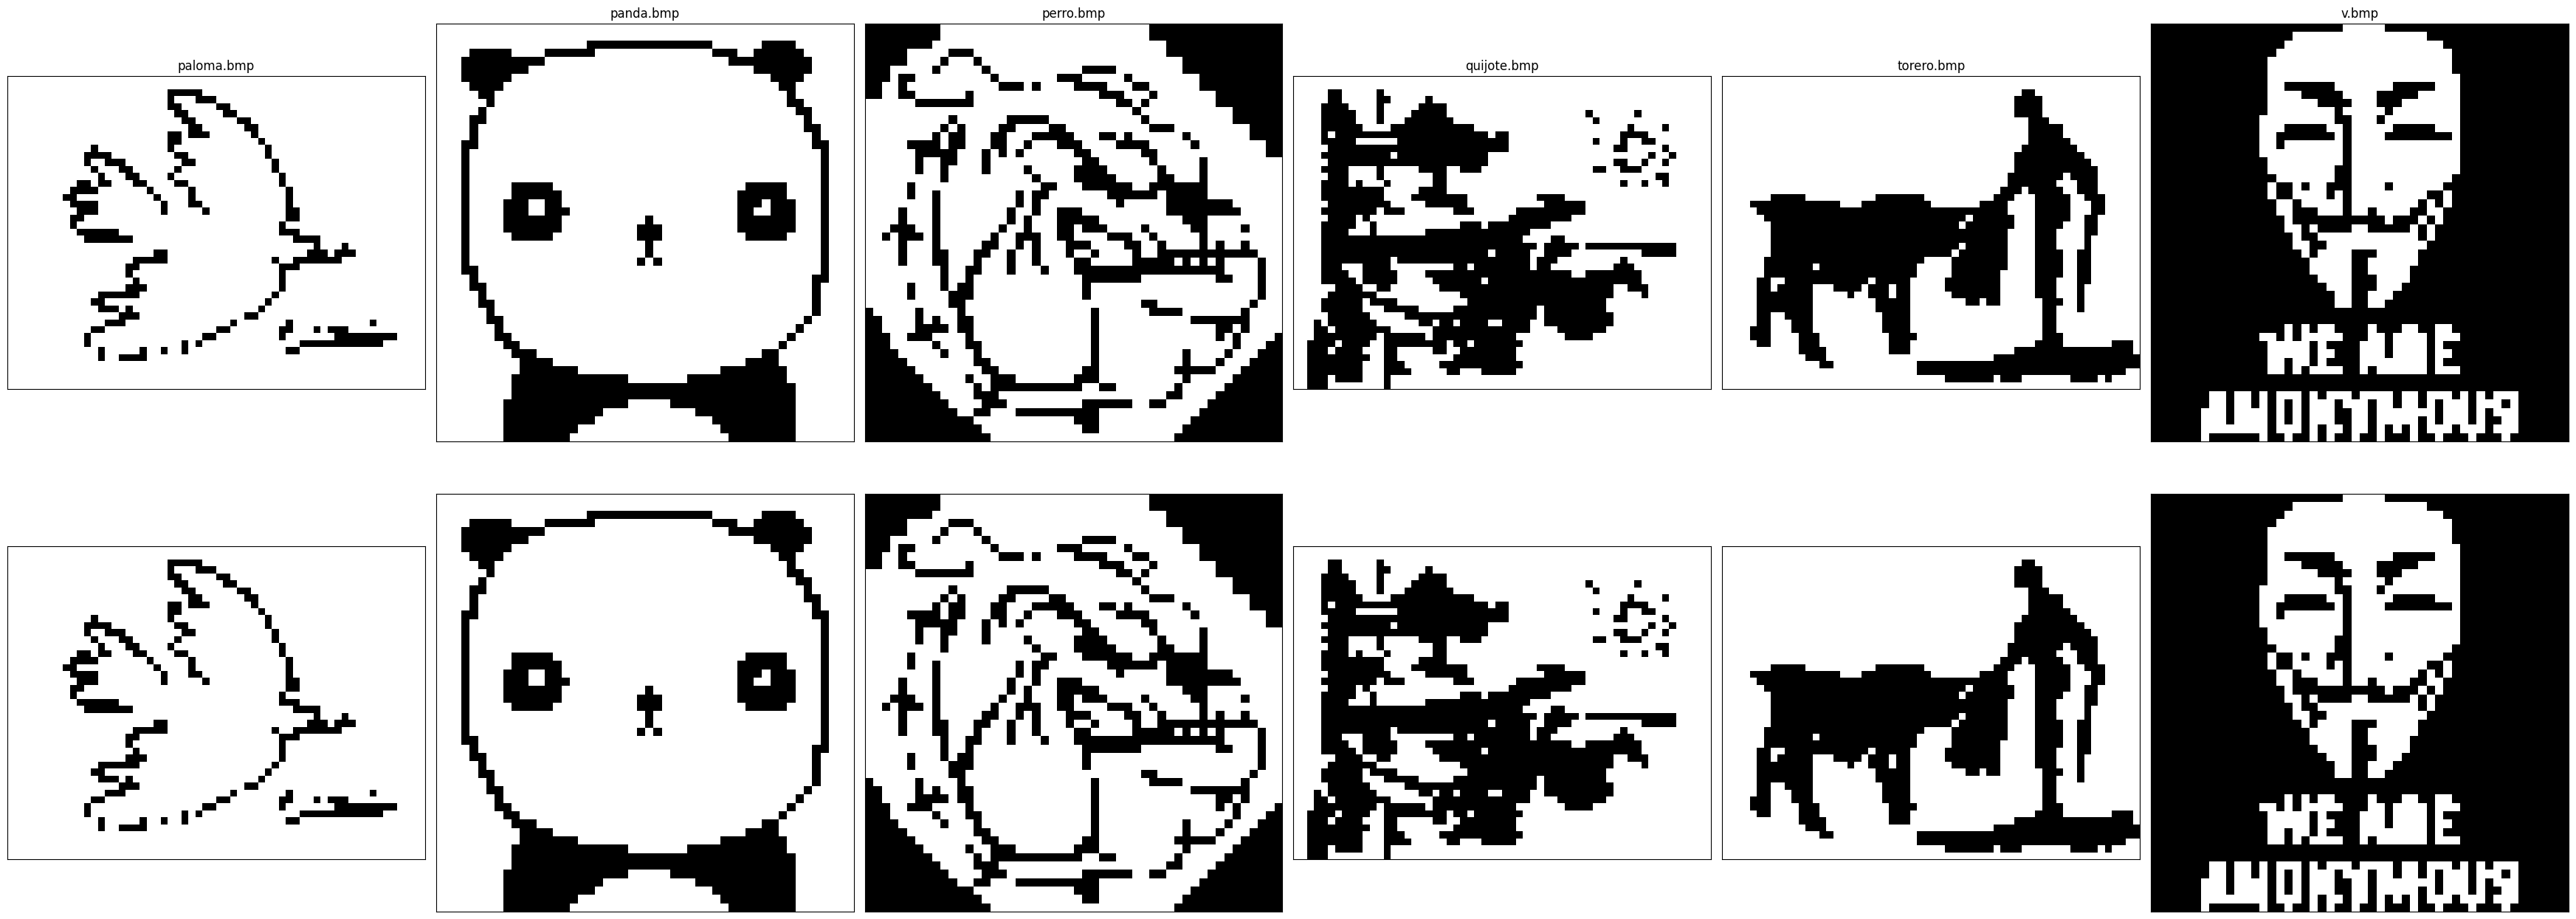

In [ ]:
dataset_train, width_max,height_max = create_dataset_from_images(images, "none")
fig, axes = plt.subplots(2, 6, figsize=(35, 15))
i = 0

for image in dataset_train:
    width = image.shape[1]
    height = image.shape[0]
    W = train_hopfield([image], width, height)

    axes[0, i].imshow(image, cmap='gray')
    axes[0, i].set_title(str(images[i]))
    axes[0, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    Y = test_hopfield(W, image)
    img = Y.reshape((height, width))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    i += 1

plt.subplots_adjust(wspace=0.4, hspace=0.1)  # Decreasing vertical space with hspace

fig.tight_layout()
plt.show()

# Perturbations introduced to images

In [ ]:
def add_noise(X, noise_level=0.5):
    X_noisy = np.copy(X)
    num_pixels = X.size
    num_noisy_pixels = int(num_pixels * noise_level)
    indices = np.random.choice(num_pixels, num_noisy_pixels, replace=False)
    X_noisy.flat[indices] *= -1  # Flip the selected pixels
    return X_noisy

def keep_rectangle(img, top_left_x, top_left_y, rect_width, rect_height, width_max, height_max):
    img_copy = np.copy(img)
    if len(img_copy.shape)==1:
      img_copy = img_copy.reshape((height_max, width_max))

    img_copy = np.ones_like(img_copy)

    # Ensure the rectangle stays within the bounds of the image
    bottom_right_x = min(top_left_x + rect_width, img.shape[1])
    bottom_right_y = min(top_left_y + rect_height, img.shape[0])

    # Keep only the selected rectangle
    img_copy[top_left_y:bottom_right_y, top_left_x:bottom_right_x] = img[top_left_y:bottom_right_y, top_left_x:bottom_right_x]

    return img_copy



test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


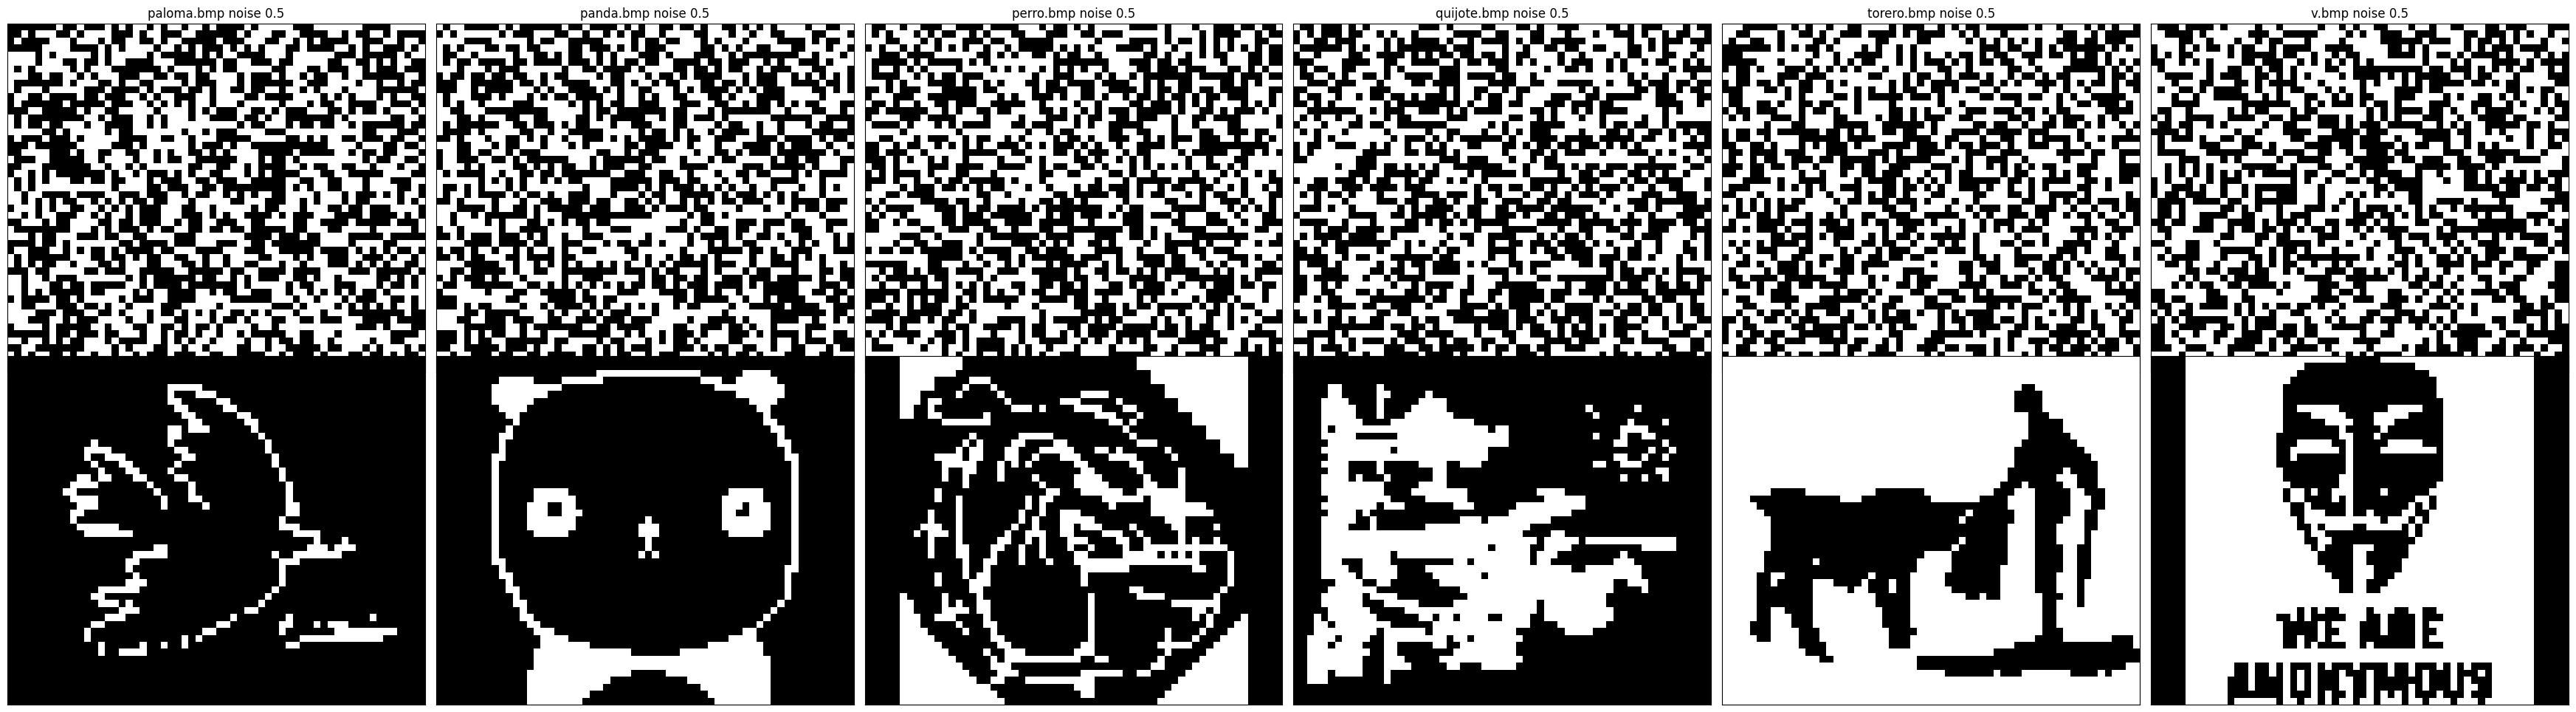

test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


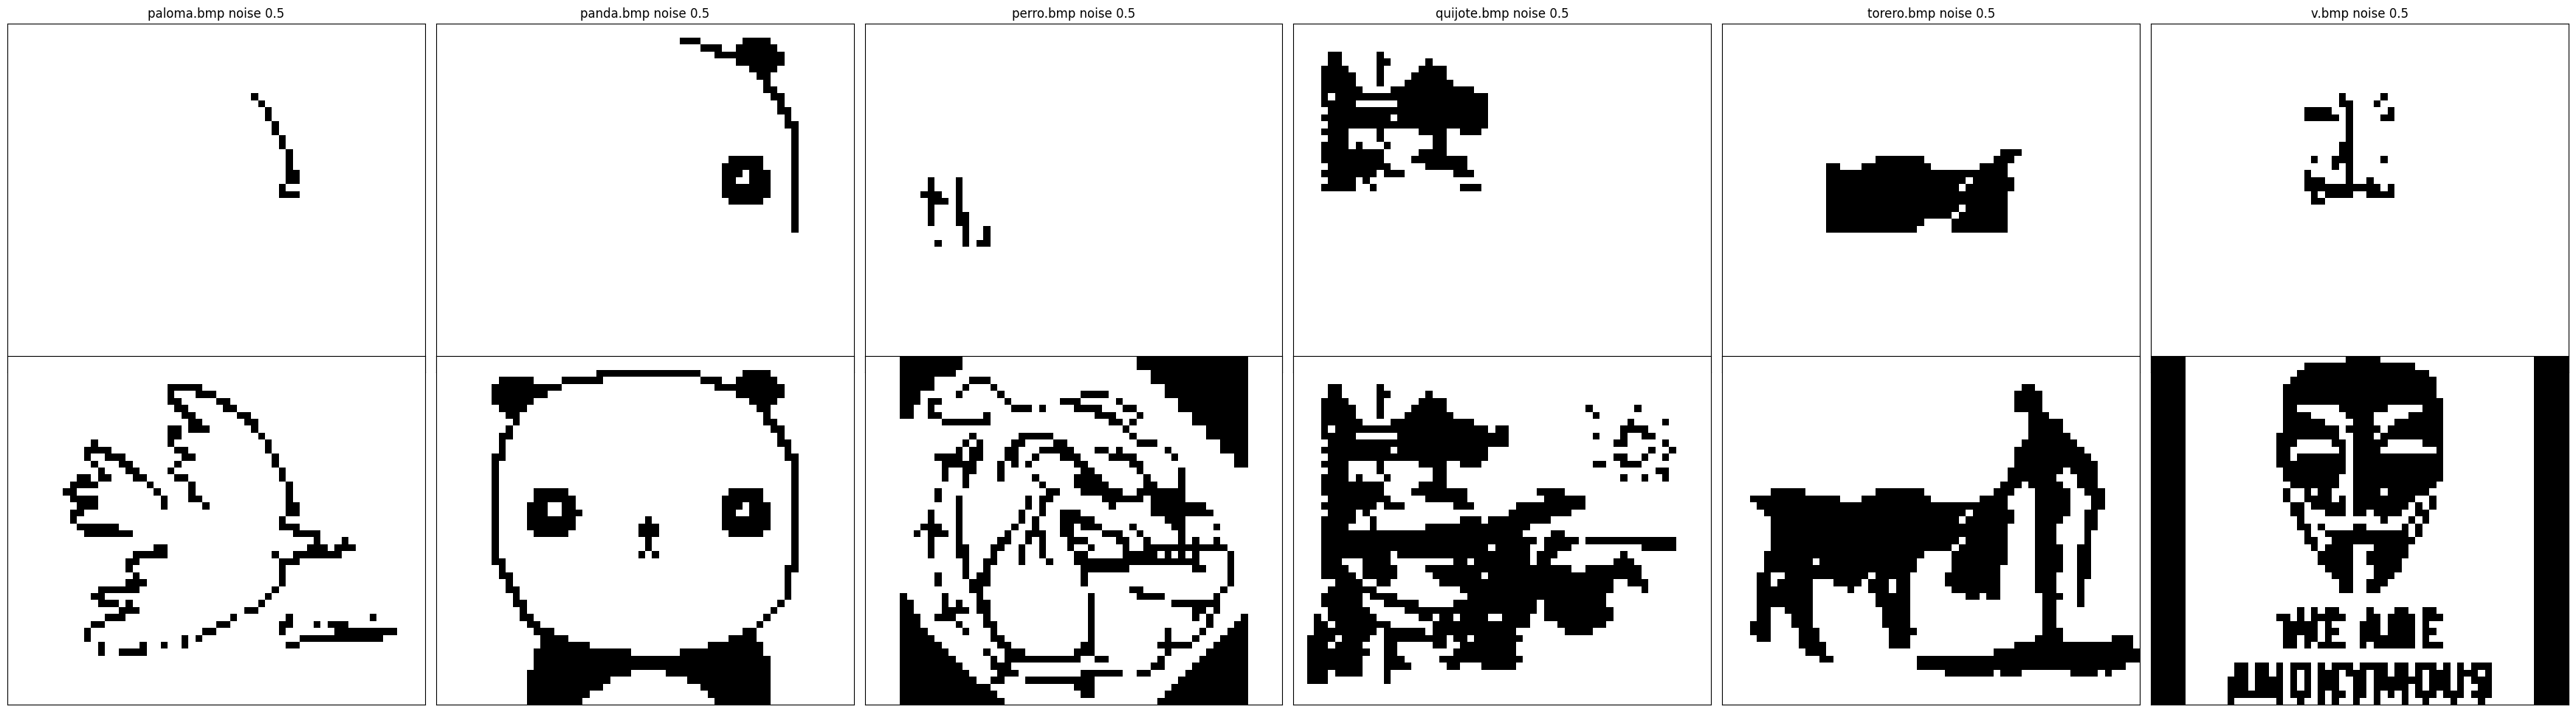

In [ ]:
############################### FOR NOISE ##############################
fig, axes = plt.subplots(2, 6, figsize=(35, 10))
noise_level=0.5
i = 0
for image in dataset_train_white:
    W = train_hopfield([image], width_max, height_max)
    noisy_pattern = add_noise(image, noise_level=noise_level)

    axes[0, i].imshow(noisy_pattern, cmap='gray')
    axes[0, i].set_title(str(images[i]) + " noise " + str(noise_level))
    axes[0, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    Y = test_hopfield(W, noisy_pattern)
    img = Y.reshape((height_max, width_max))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    i += 1

plt.subplots_adjust(wspace=0.4, hspace=0.1)  # Decreasing vertical space with hspace

fig.tight_layout()
plt.show()


############################### FOR RECTANGLES ##############################
fig, axes = plt.subplots(2, 6, figsize=(35, 10))
noise_level=0.5
i = 0
for image in dataset_train_white:
    # Randomly determine the width and height of the rectangle
    rect_width = np.random.randint(10, 30)
    rect_height = np.random.randint(10, 30)

    # Randomly select the top-left corner of the rectangle
    top_left_x = np.random.randint(0, width_max - rect_width)
    top_left_y = np.random.randint(0, height_max -rect_height )

    W = train_hopfield([image], width_max, height_max)

    rect_pattern = keep_rectangle(img=image, top_left_x=top_left_x,top_left_y=top_left_y,rect_width=rect_width,rect_height=rect_height,width_max=width_max,height_max=height_max)

    axes[0, i].imshow(rect_pattern, cmap='gray')
    axes[0, i].set_title(str(images[i]) + " noise " + str(noise_level))
    axes[0, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    Y = test_hopfield(W, rect_pattern)
    img = Y.reshape((height_max, width_max))
    axes[1, i].imshow(img, cmap='gray')
    axes[1, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    i += 1

plt.subplots_adjust(wspace=0.4, hspace=0.1)  # Decreasing vertical space with hspace

fig.tight_layout()
plt.show()


# LEARNING 3 FIGURES OF SAME SIZE

## Training with images of height 45 and evaluation with noise 0.3

test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


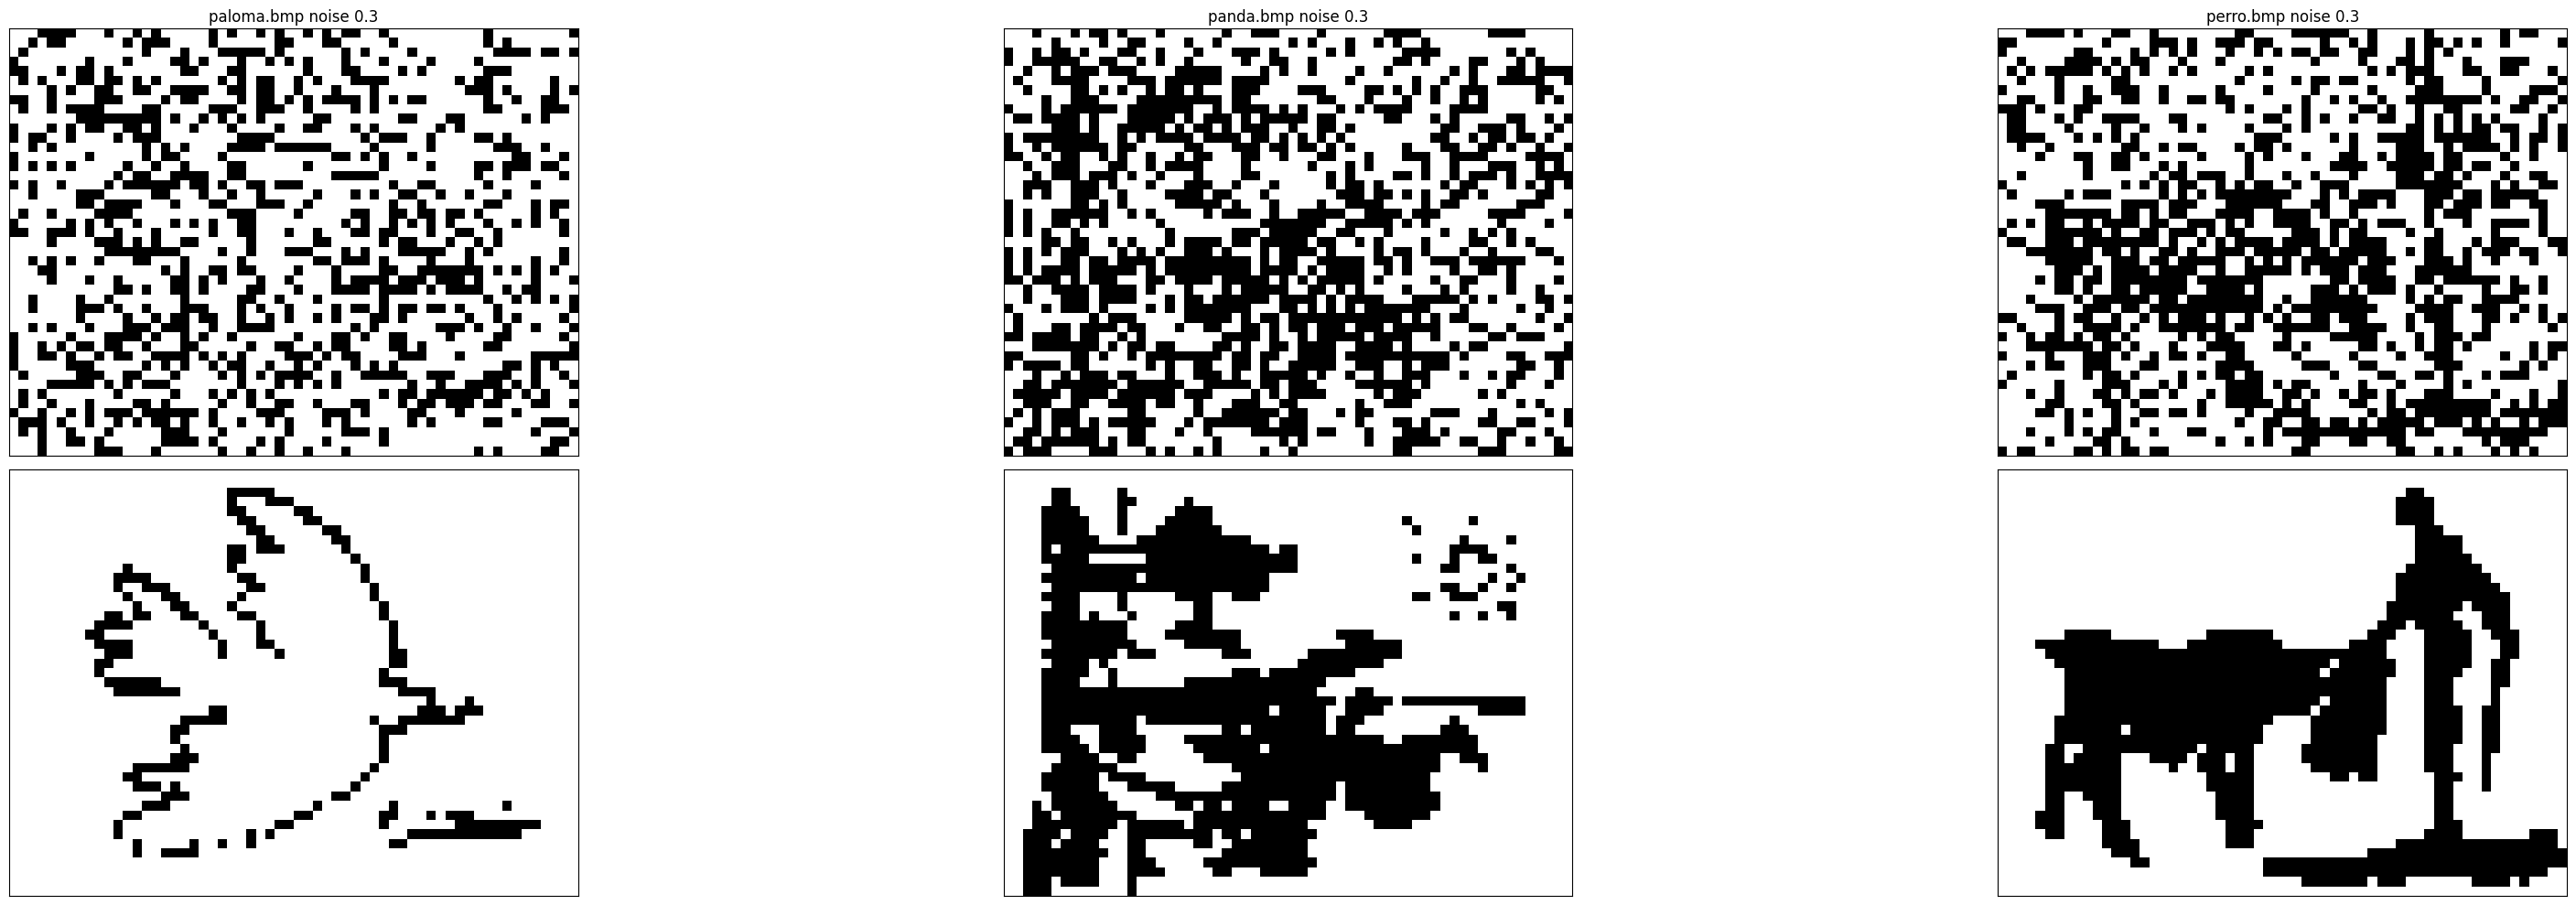

In [ ]:
width = dataset_train_45[0].shape[1]
height = dataset_train_45[0].shape[0]
W = train_hopfield(dataset_train_45,width_max=width,height_max=height)

fig, axes = plt.subplots(2, 3, figsize=(35, 10))
noise_level=0.3
i = 0
for image in dataset_train_45:
    noisy_pattern = add_noise(image, noise_level=noise_level)

    axes[0, i].imshow(noisy_pattern, cmap='gray')
    axes[0, i].set_title(str(images[i]) + " noise " + str(noise_level))
    axes[0, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    Y = test_hopfield(W, noisy_pattern)
    Y=Y.reshape(height,width)
    axes[1, i].imshow(Y, cmap='gray')
    axes[1, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    i += 1

plt.subplots_adjust(wspace=0.4, hspace=0.1)  # Decreasing vertical space with hspace

fig.tight_layout()
plt.show()



## Training with images of height 50 and evaluation with noise 0.3



test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


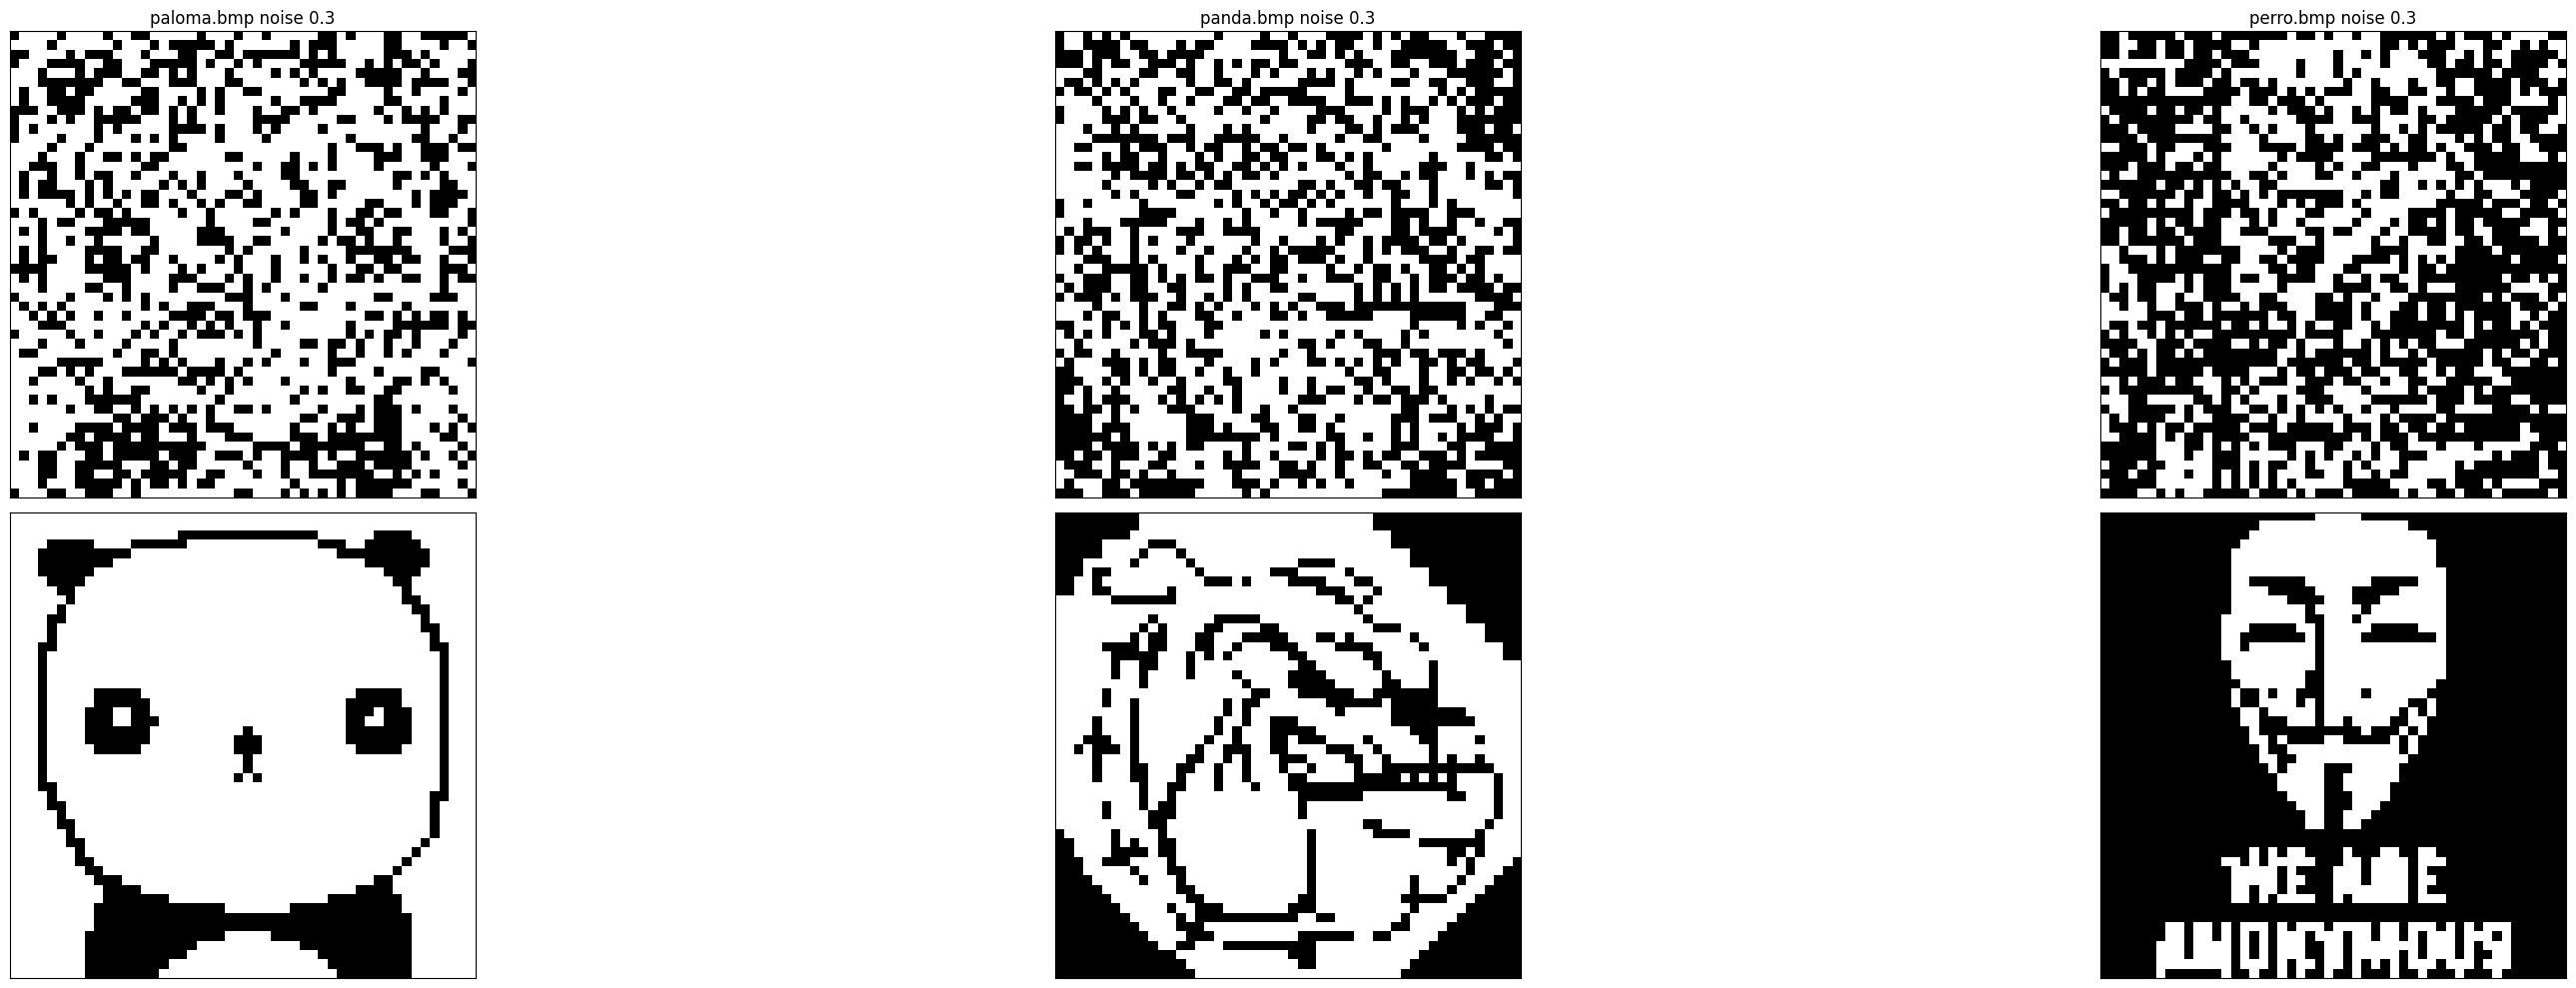

In [ ]:
width = dataset_train_50[0].shape[1]
height = dataset_train_50[0].shape[0]
W = train_hopfield(dataset_train_50, width_max =dataset_train_50[0].shape[1] , height_max=dataset_train_50[0].shape[0])

fig, axes = plt.subplots(2, 3, figsize=(35, 10))
noise_level=0.3
i = 0
for image in dataset_train_50:
    noisy_pattern = add_noise(image, noise_level=noise_level)

    axes[0, i].imshow(noisy_pattern, cmap='gray')
    axes[0, i].set_title(str(images[i]) + " noise " + str(noise_level))
    axes[0, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    Y = test_hopfield(W, noisy_pattern)
    Y=Y.reshape(height,width)
    axes[1, i].imshow(Y, cmap='gray')
    axes[1, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

    i += 1

plt.subplots_adjust(wspace=0.4, hspace=0.1)  # Decreasing vertical space with hspace

fig.tight_layout()
plt.show()

# LEARNING THE 6 FIGURES

## Here the learning is sequential, by adding one more figure each time.
To make the images of the same size, a white padding is added


test finished after 1 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


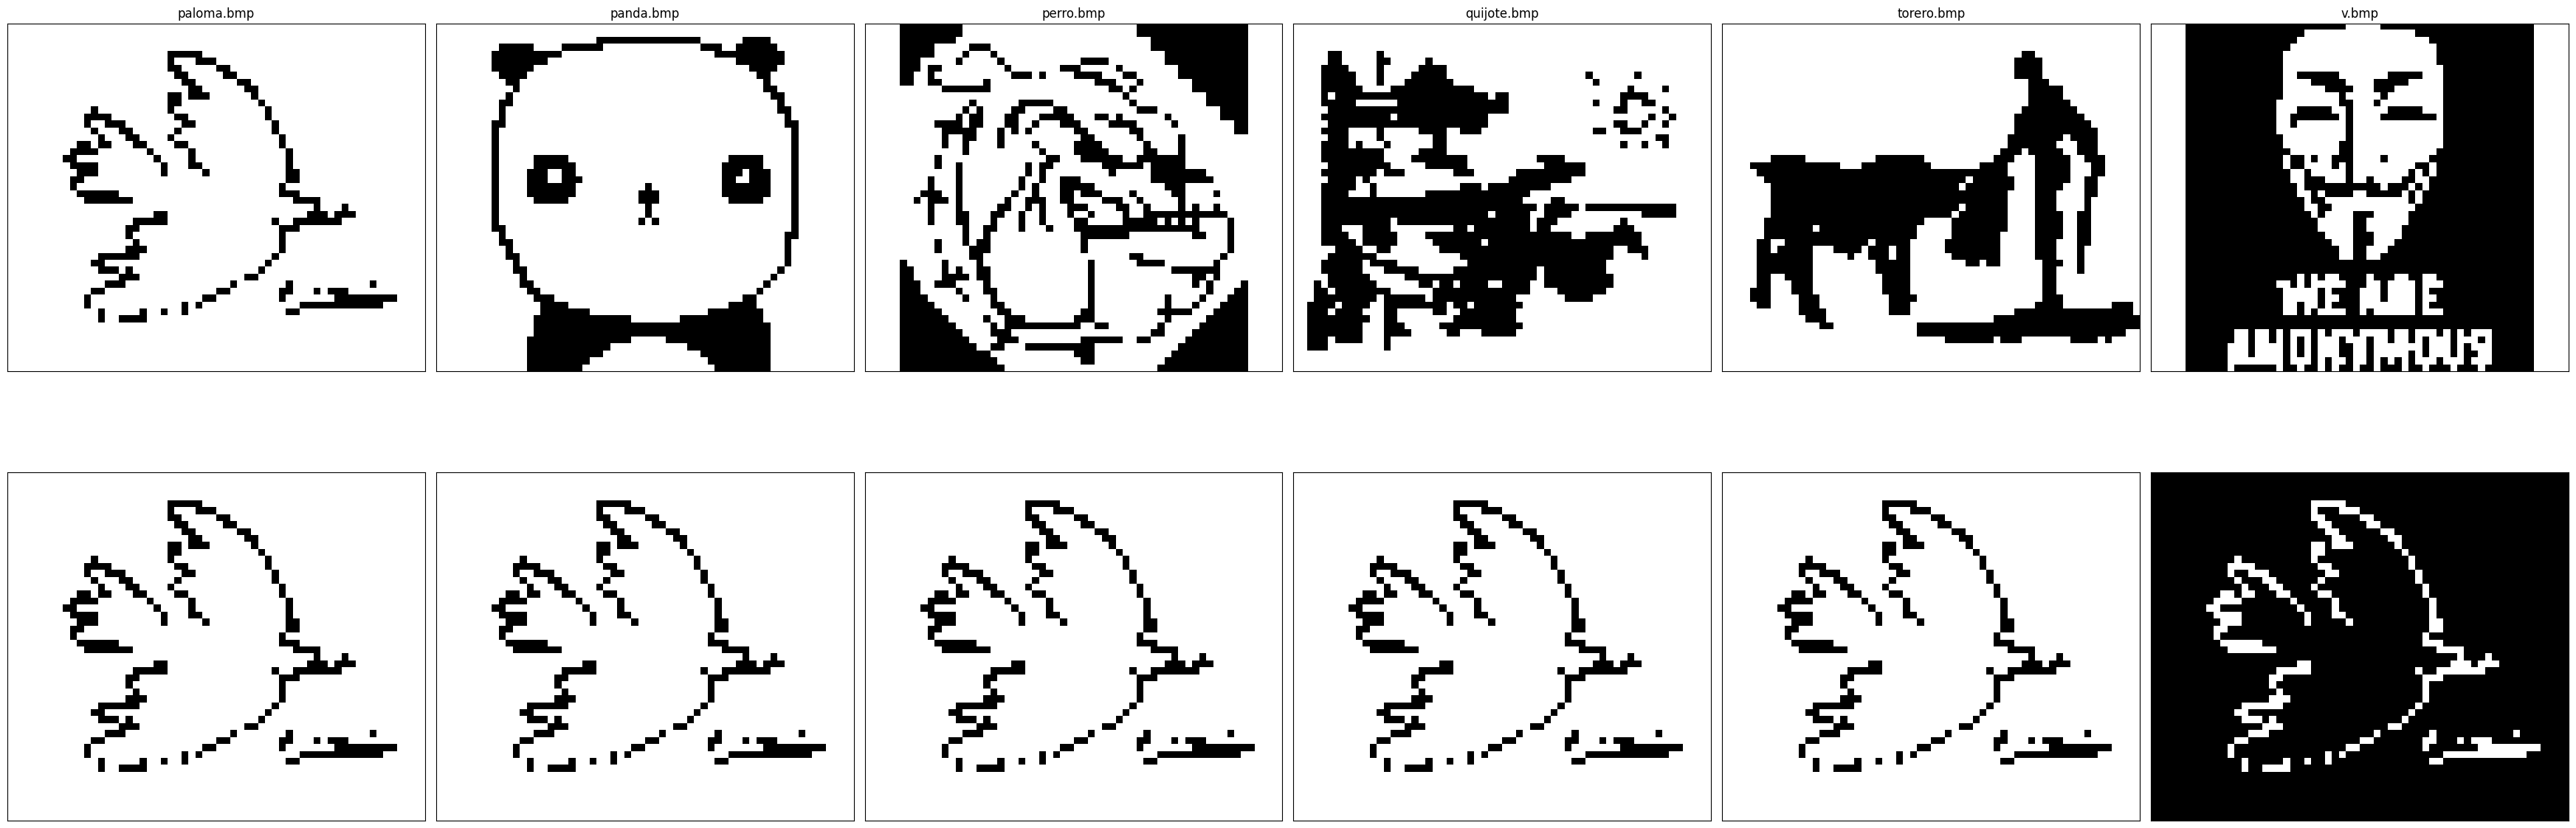

test finished after 1 iterations
test finished after 1 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


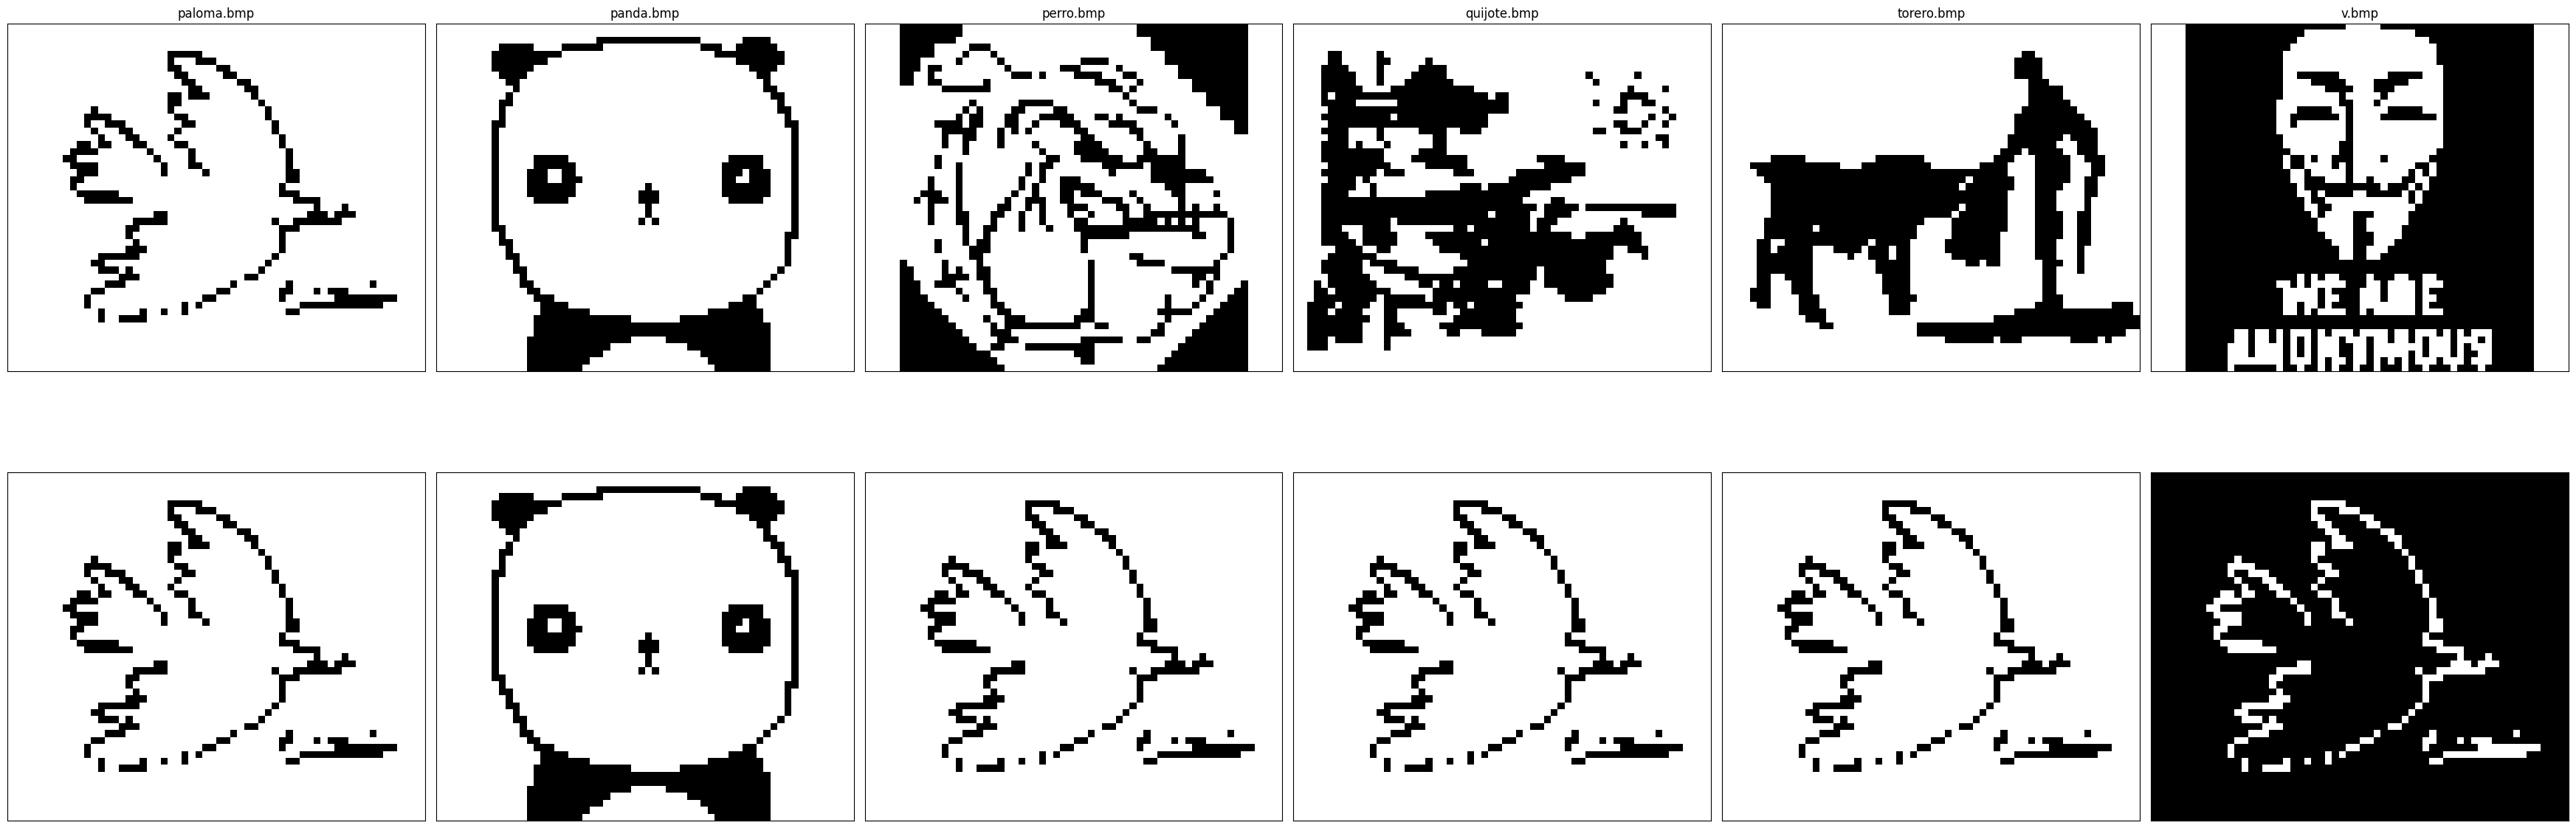

test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


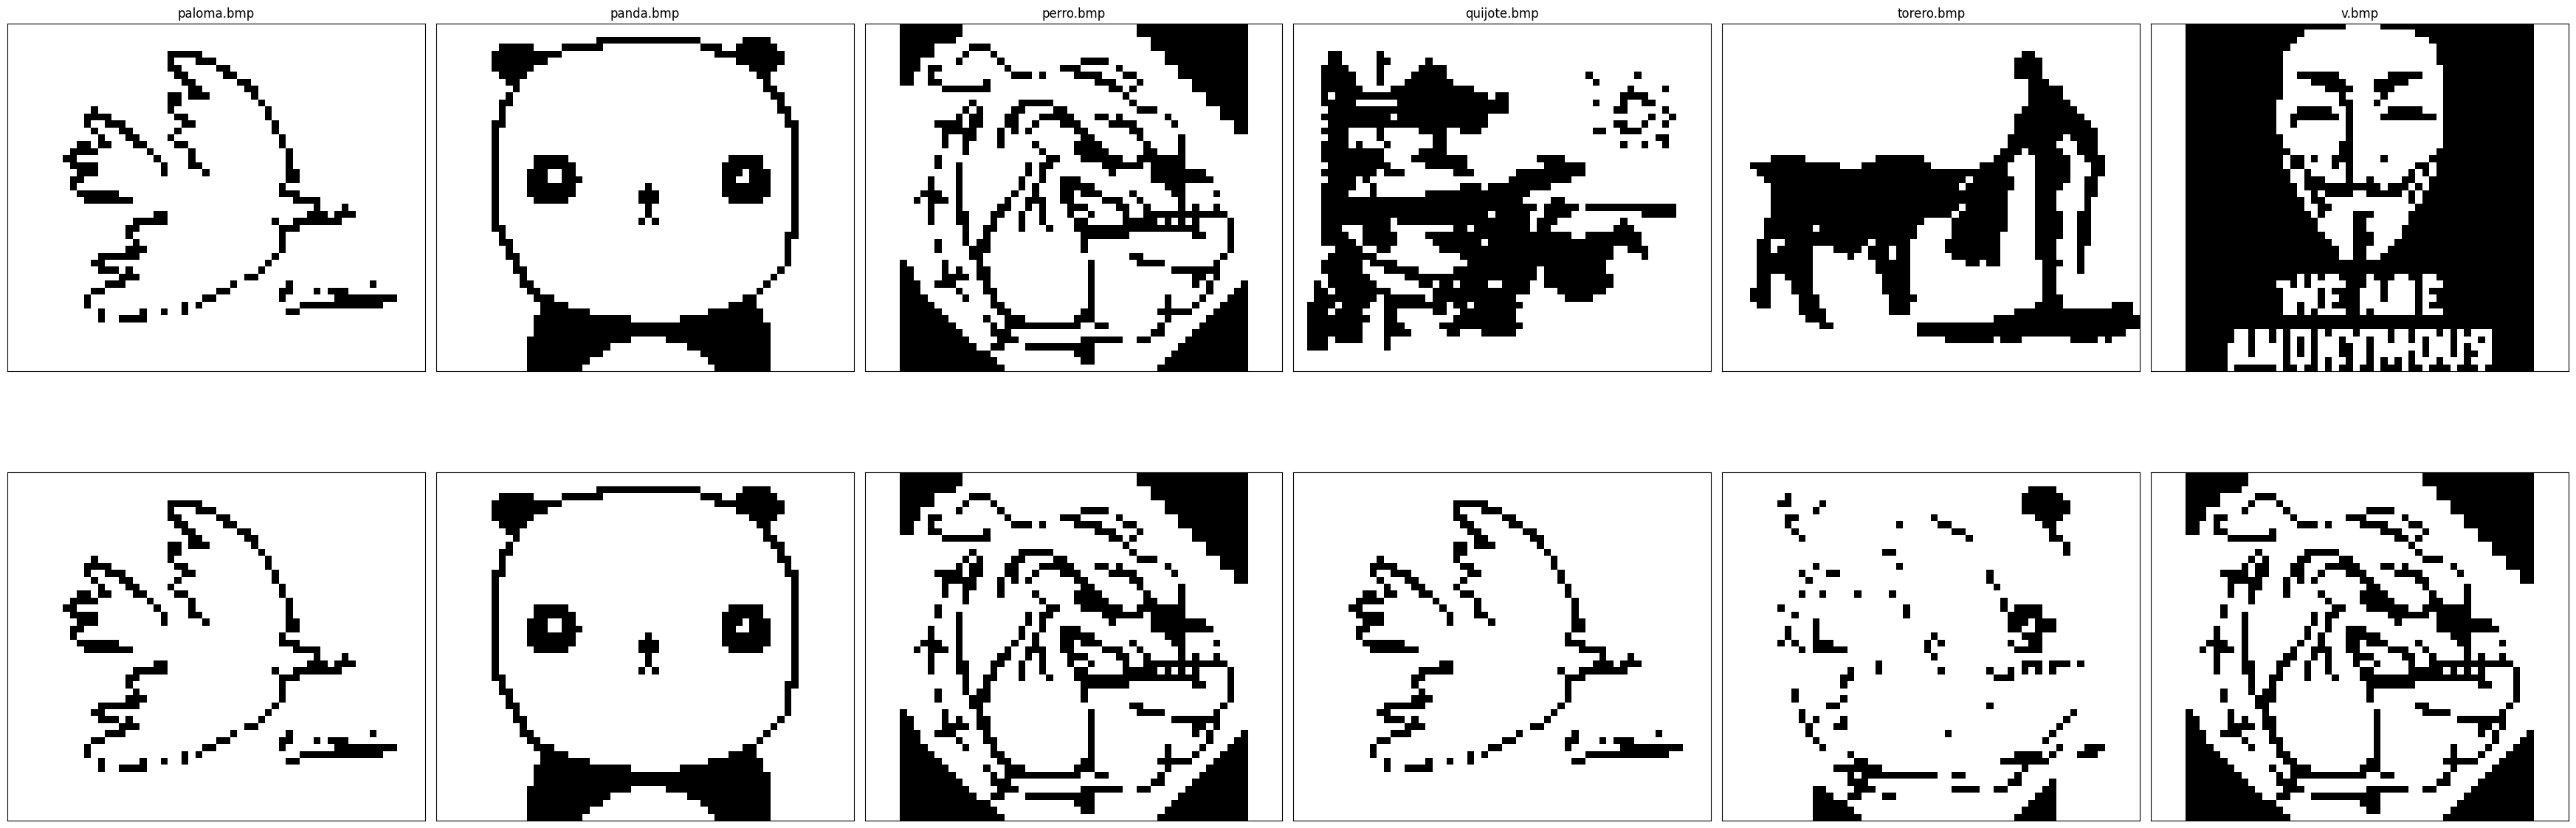

test finished after 2 iterations
test finished after 3 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 3 iterations
test finished after 2 iterations


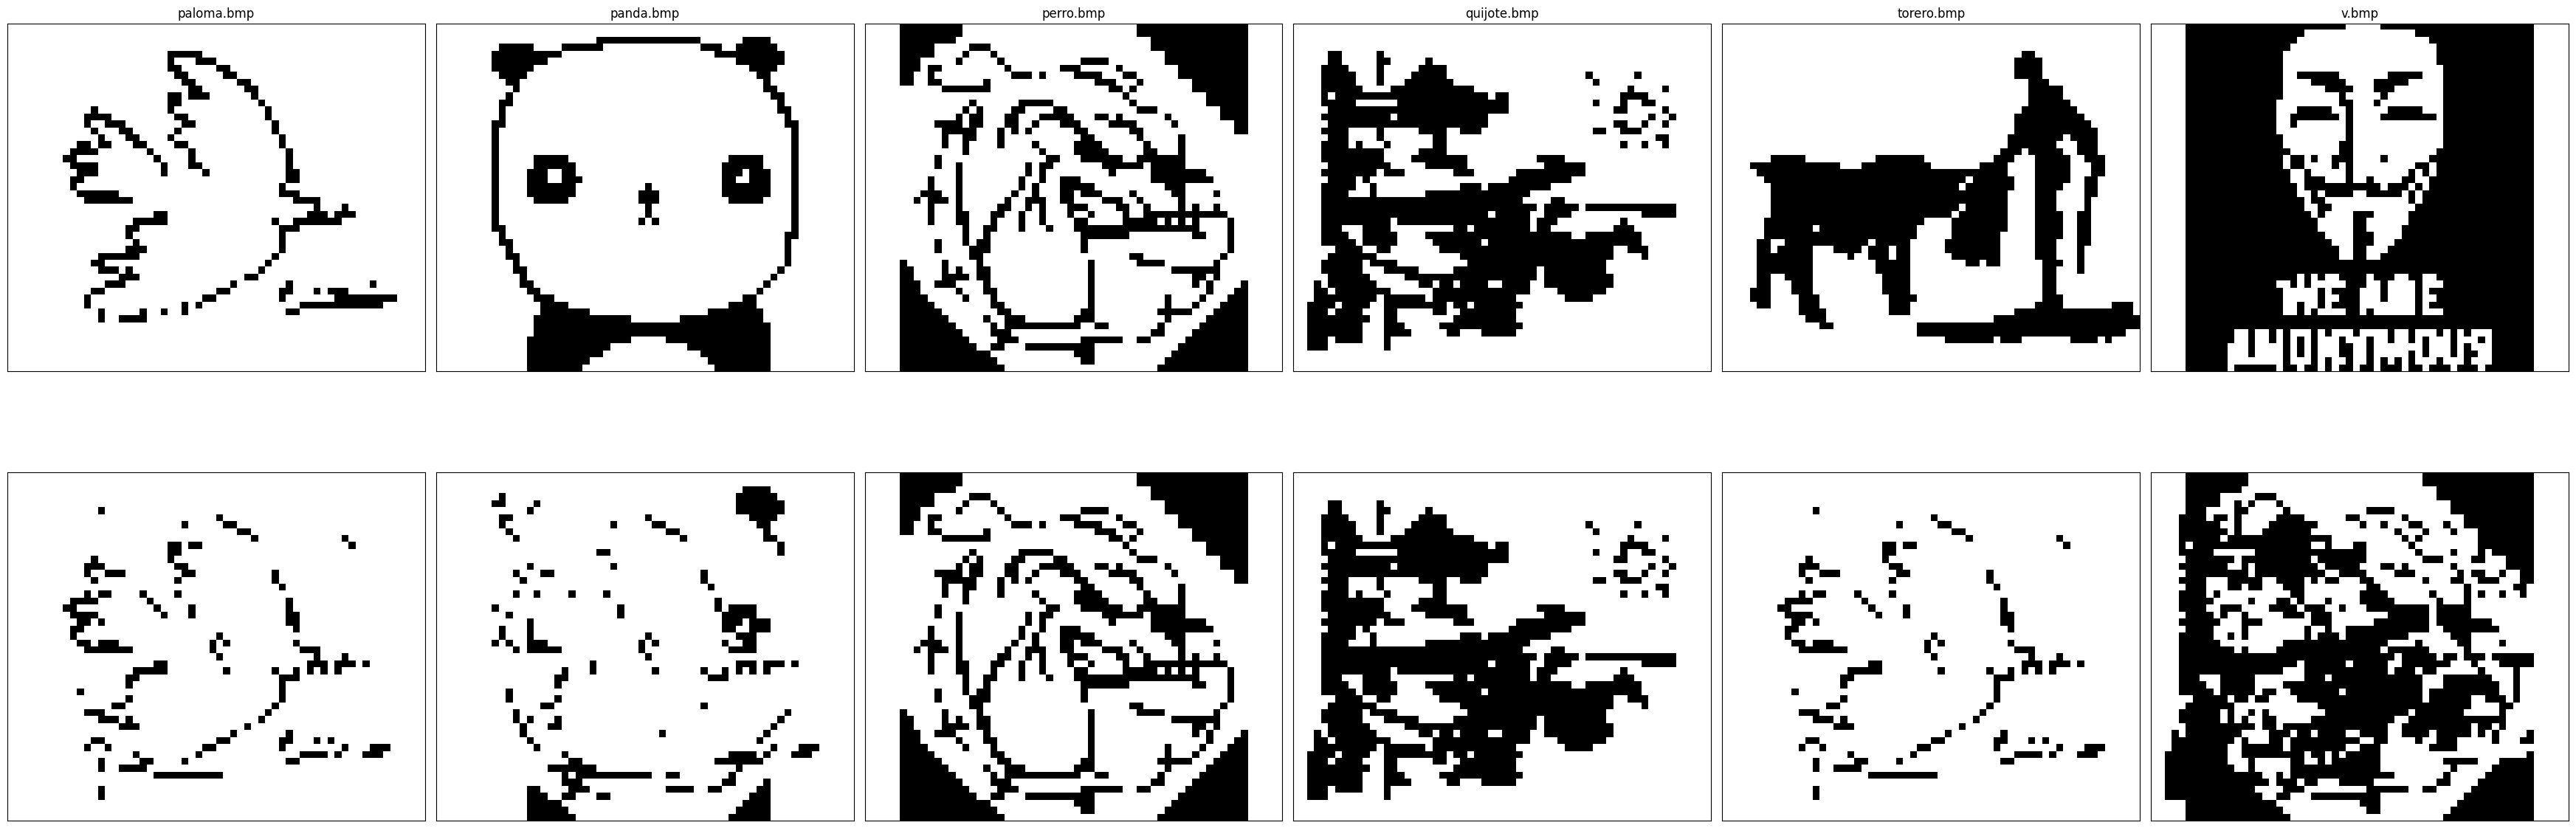

test finished after 3 iterations
test finished after 3 iterations
test finished after 3 iterations
test finished after 1 iterations
test finished after 4 iterations
test finished after 3 iterations


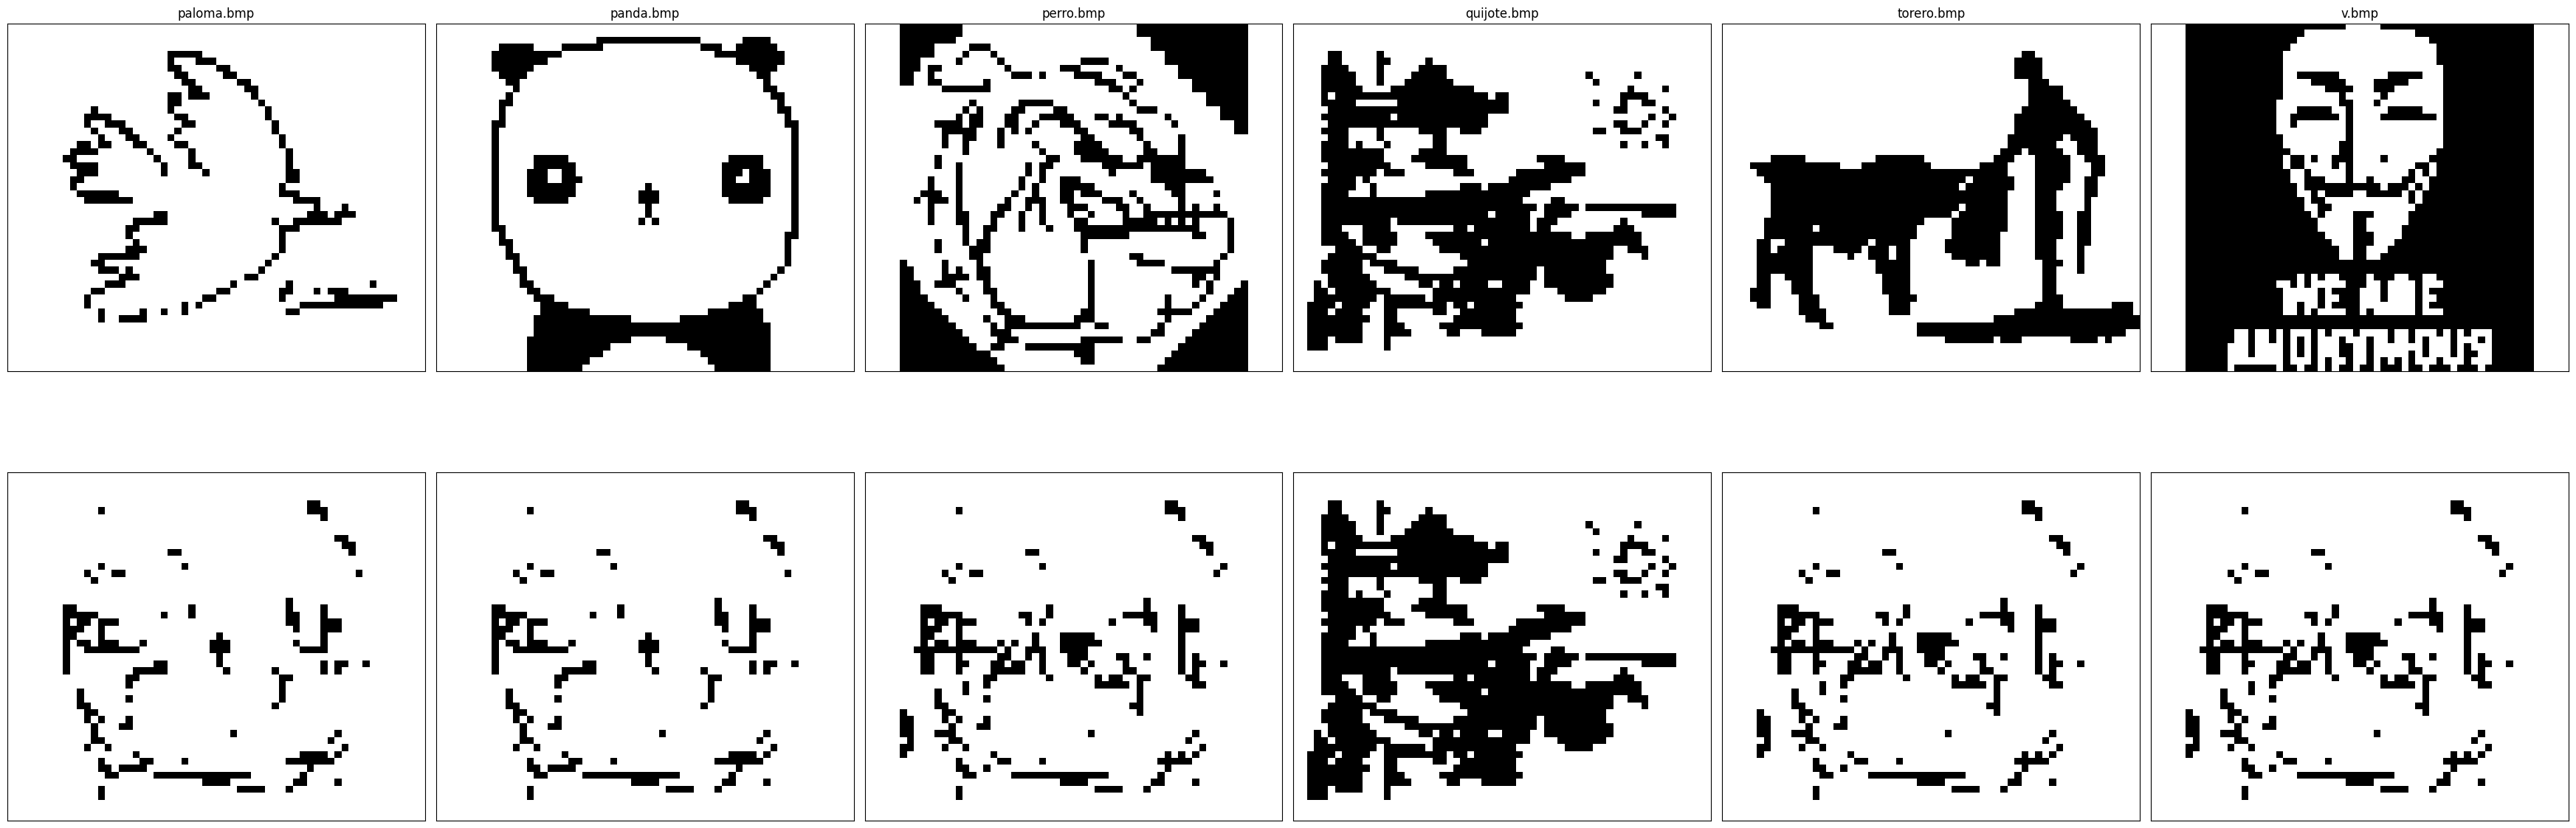

test finished after 4 iterations
test finished after 3 iterations
test finished after 5 iterations
test finished after 1 iterations
test finished after 4 iterations
test finished after 1 iterations


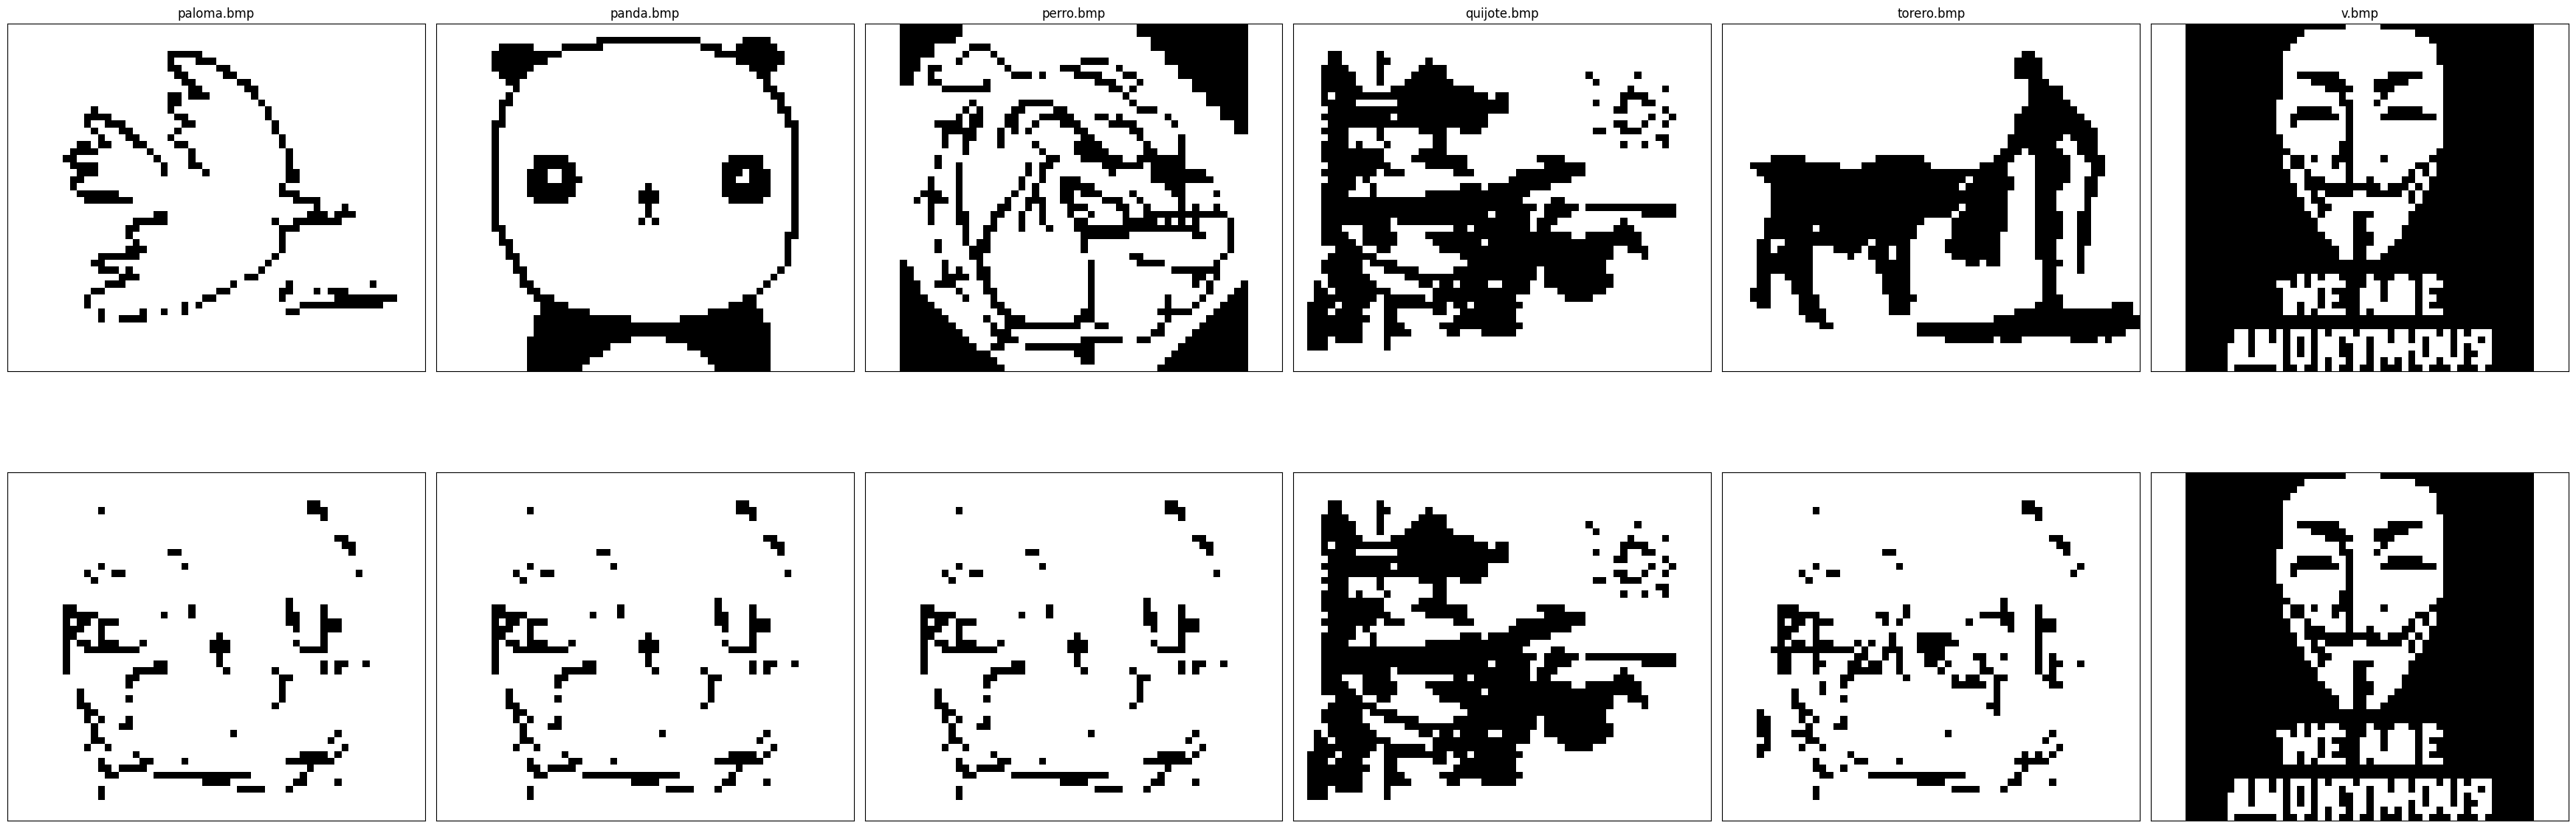

In [ ]:

dataset_train, width_max,height_max = create_dataset_from_images(images,"white")

for j in range(len(dataset_train)):

  # Train the Hopfield network
  W = train_hopfield(dataset_train[:j+1], width_max, height_max)

  fig, axes = plt.subplots(2, 6, figsize=(35, 15))

  i = 0
  for image in dataset_train:
      plt.imshow(W)
      axes[0, i].imshow(image, cmap='gray')
      axes[0, i].set_title(str(images[i]))
      axes[0, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

      Y = test_hopfield(W, image)
      img = Y.reshape((height_max, width_max))
      axes[1, i].imshow(img, cmap='gray')
      axes[1, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

      i += 1

  plt.subplots_adjust(wspace=0.4, hspace=0.1)

  fig.tight_layout()

  plt.show()



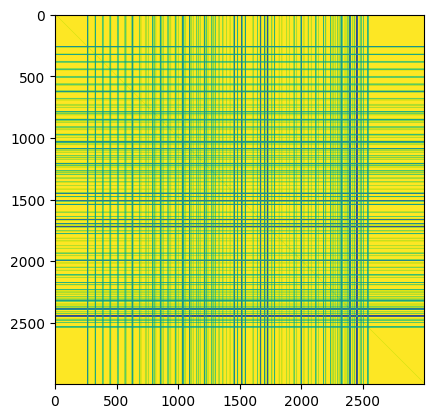

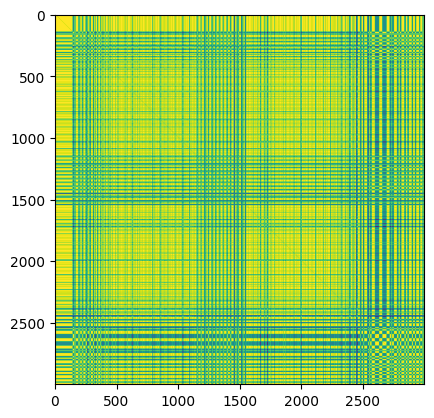

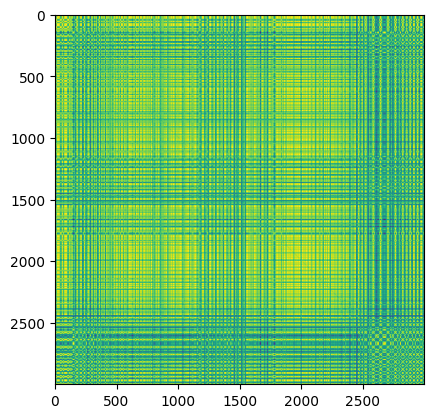

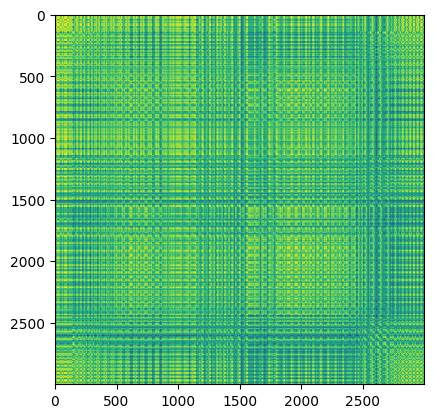

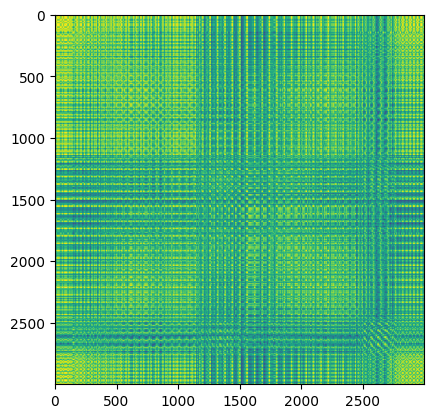

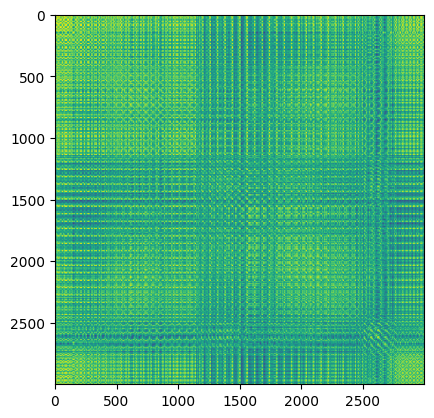

In [ ]:
dataset_train_white, width_max,height_max = create_dataset_from_images(images,"white")

for j in range(len(dataset_train_white)):

  # Train the Hopfield network
  W = train_hopfield(dataset_train[:j+1], width_max, height_max)
  plt.subplot(1, 1, 1)
  plt.imshow(W)
  plt.show()





## Here the padding is done with noise, making the result better.

test finished after 1 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


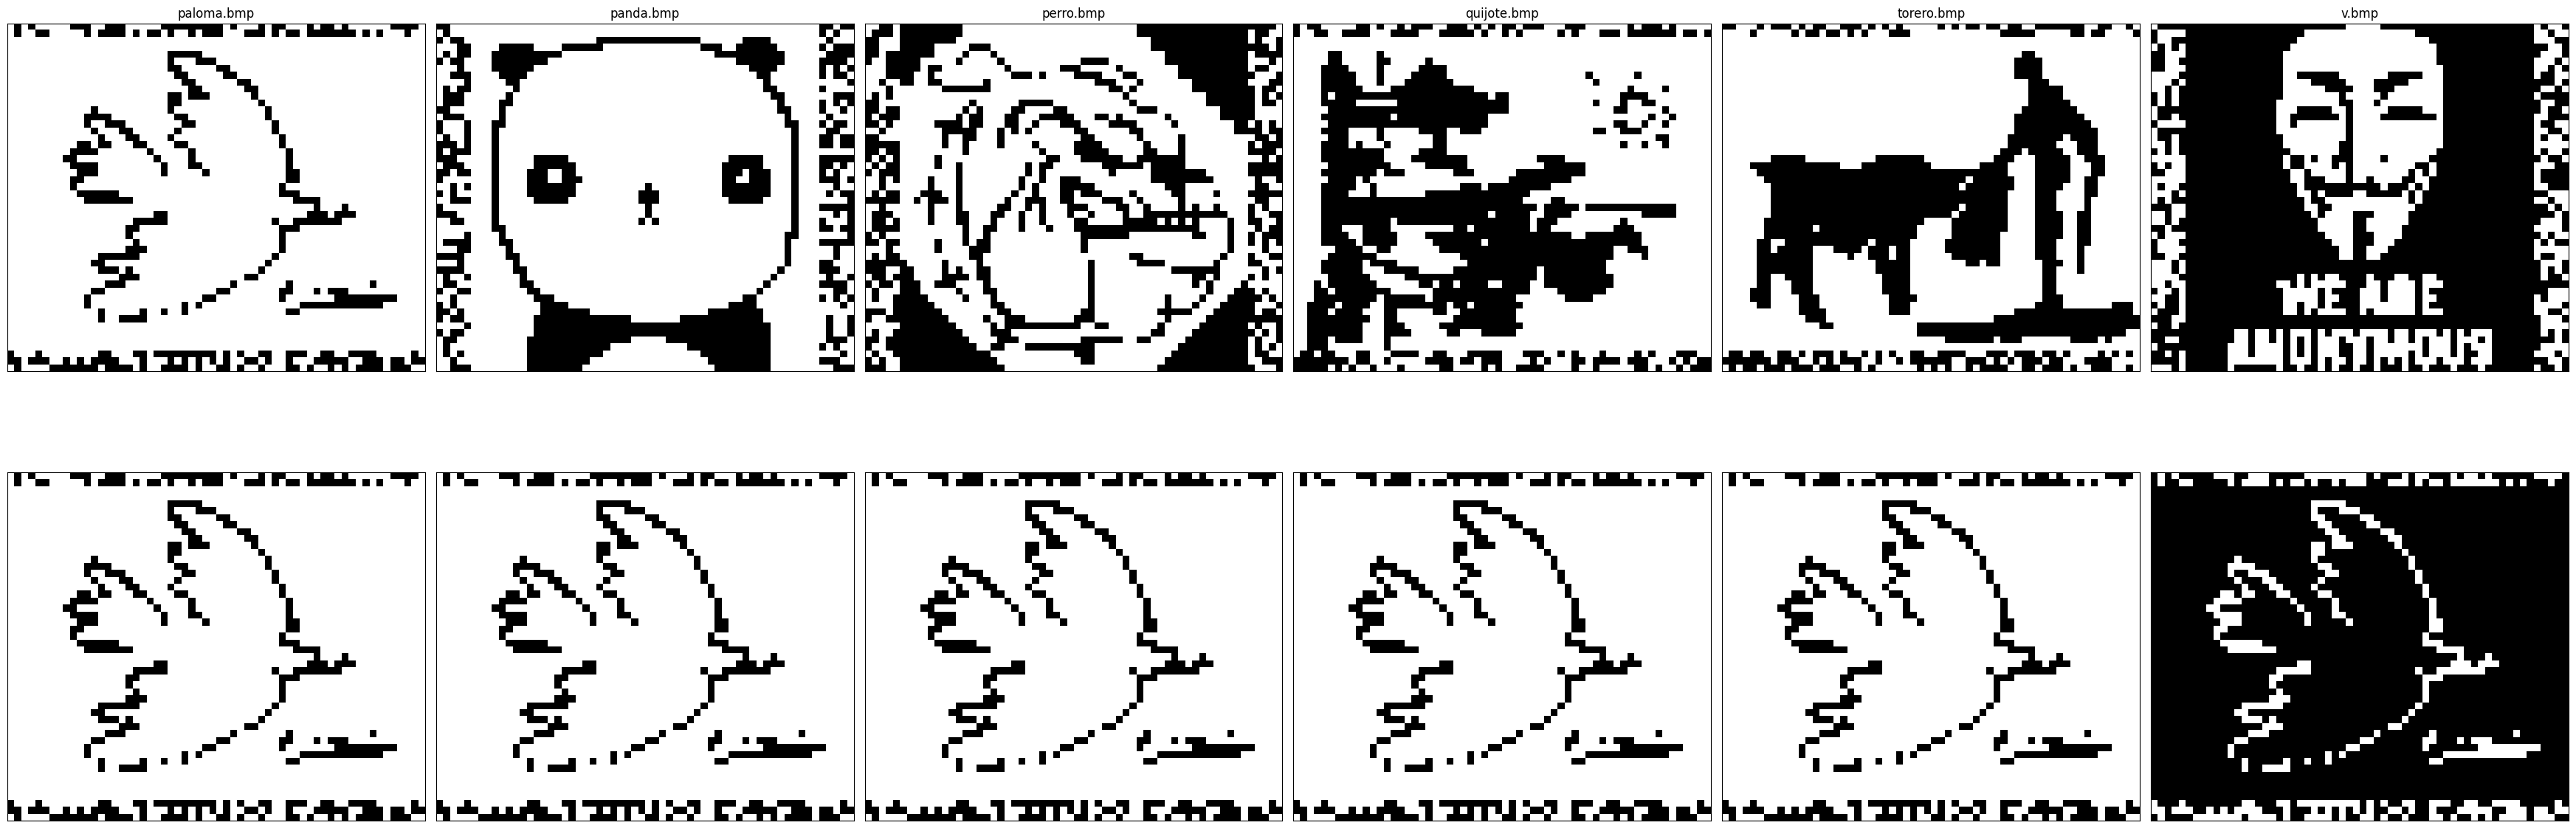

test finished after 1 iterations
test finished after 1 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


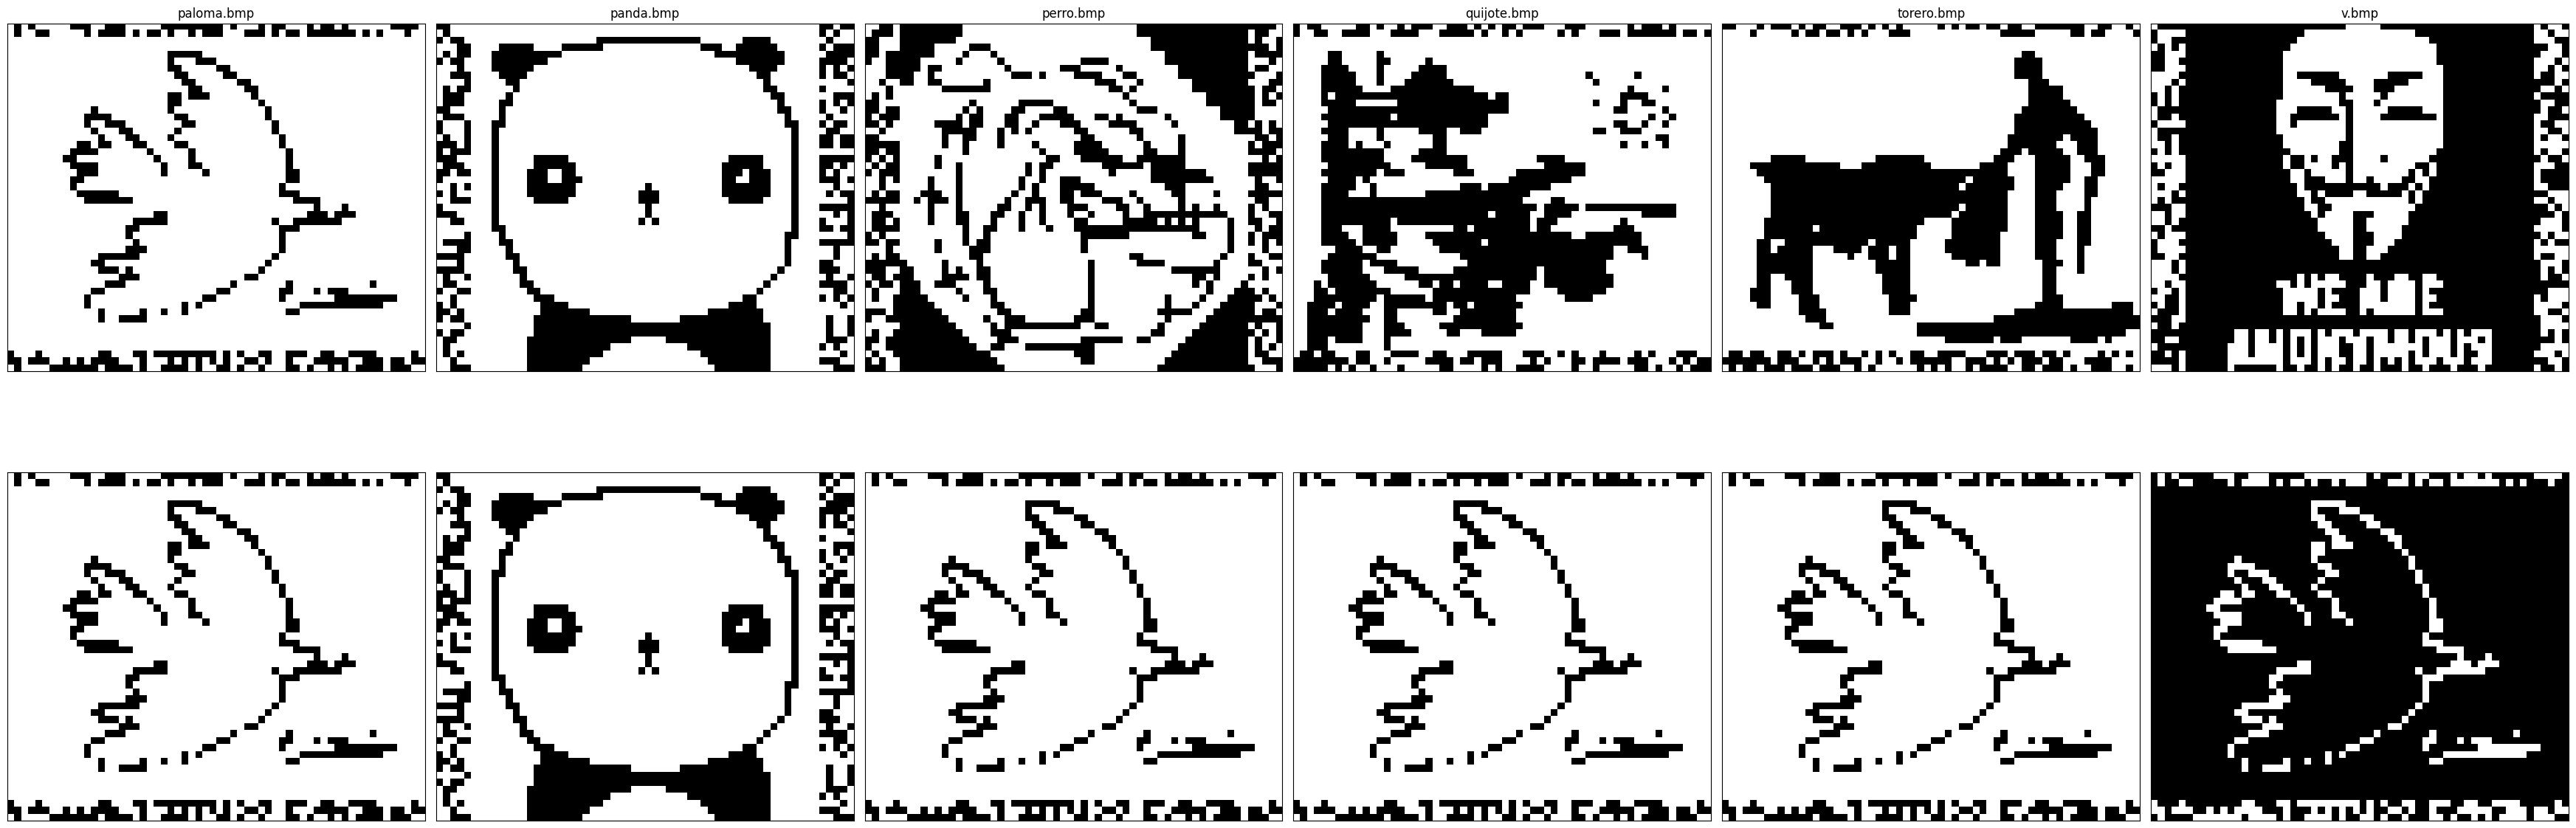

test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 2 iterations
test finished after 2 iterations
test finished after 2 iterations


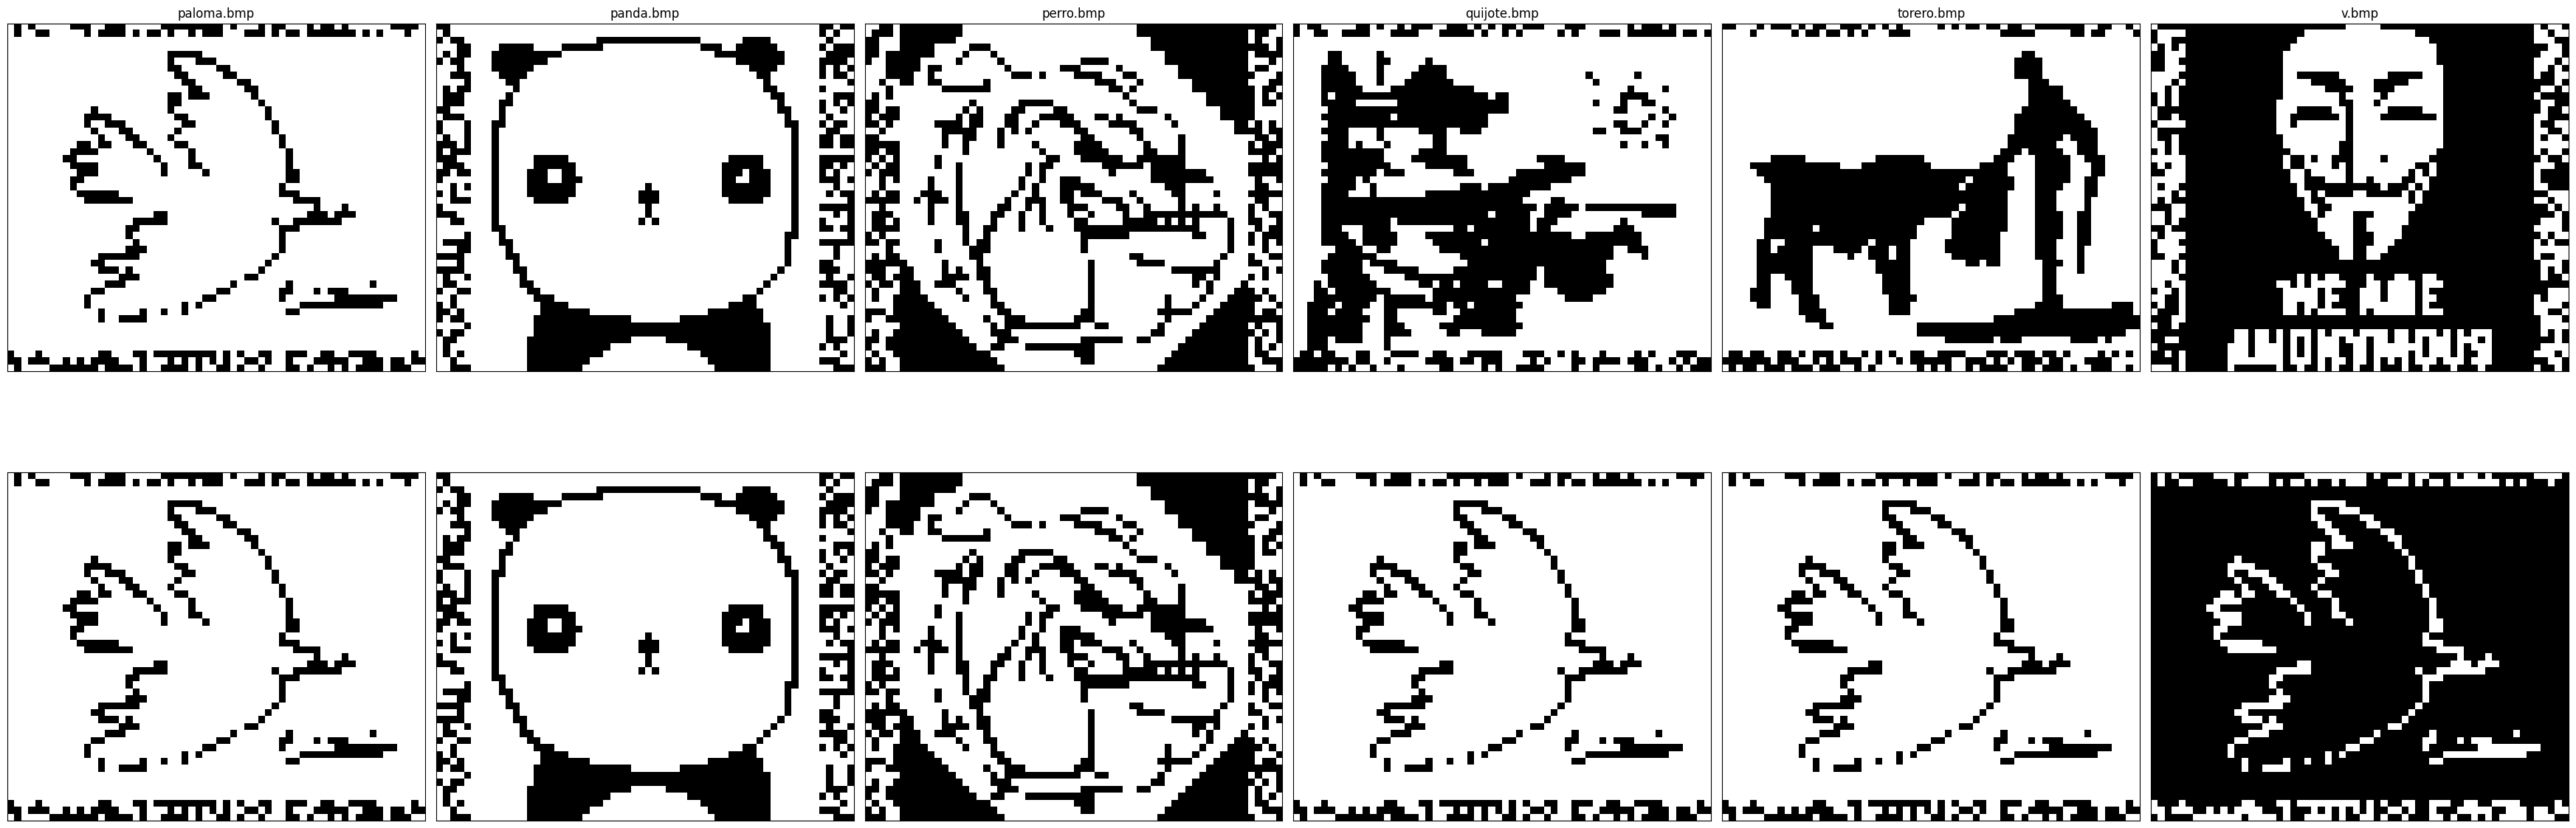

test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 3 iterations
test finished after 2 iterations


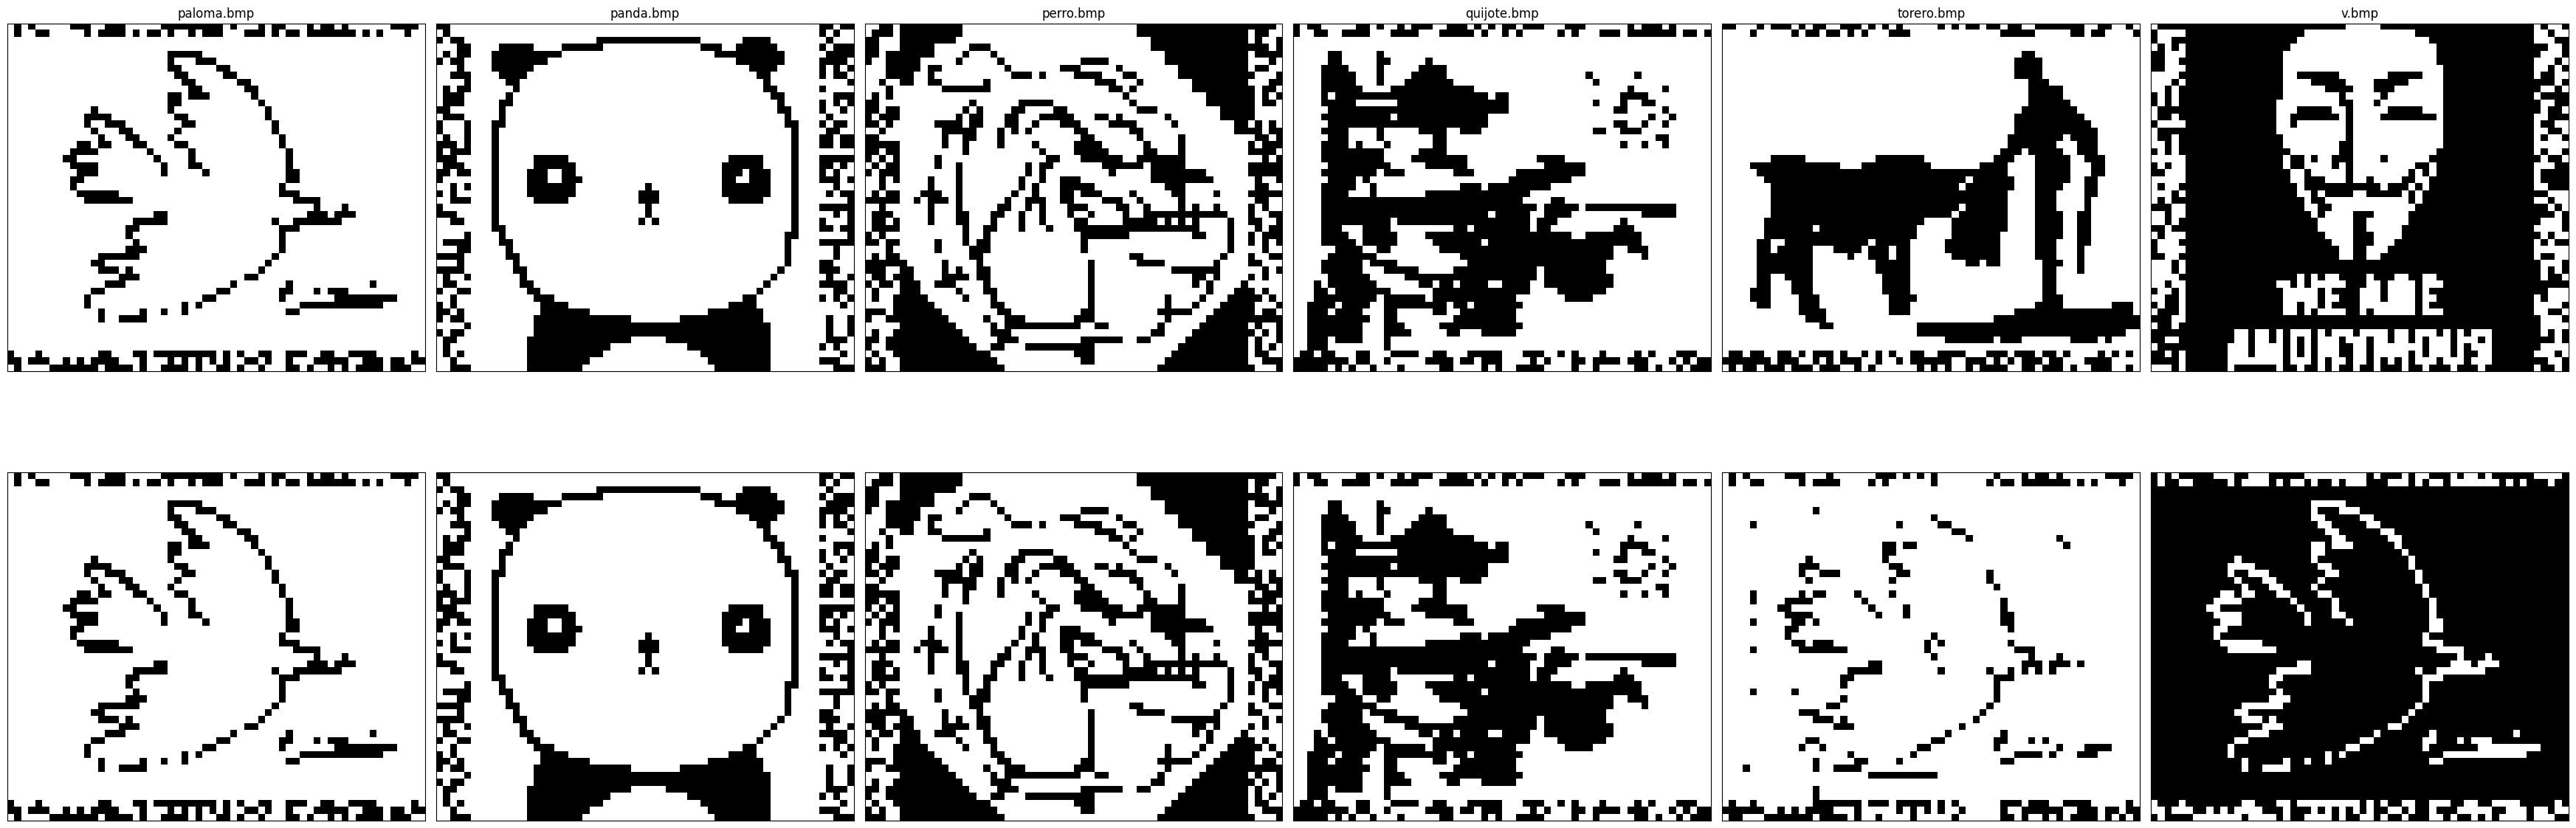

test finished after 2 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 3 iterations


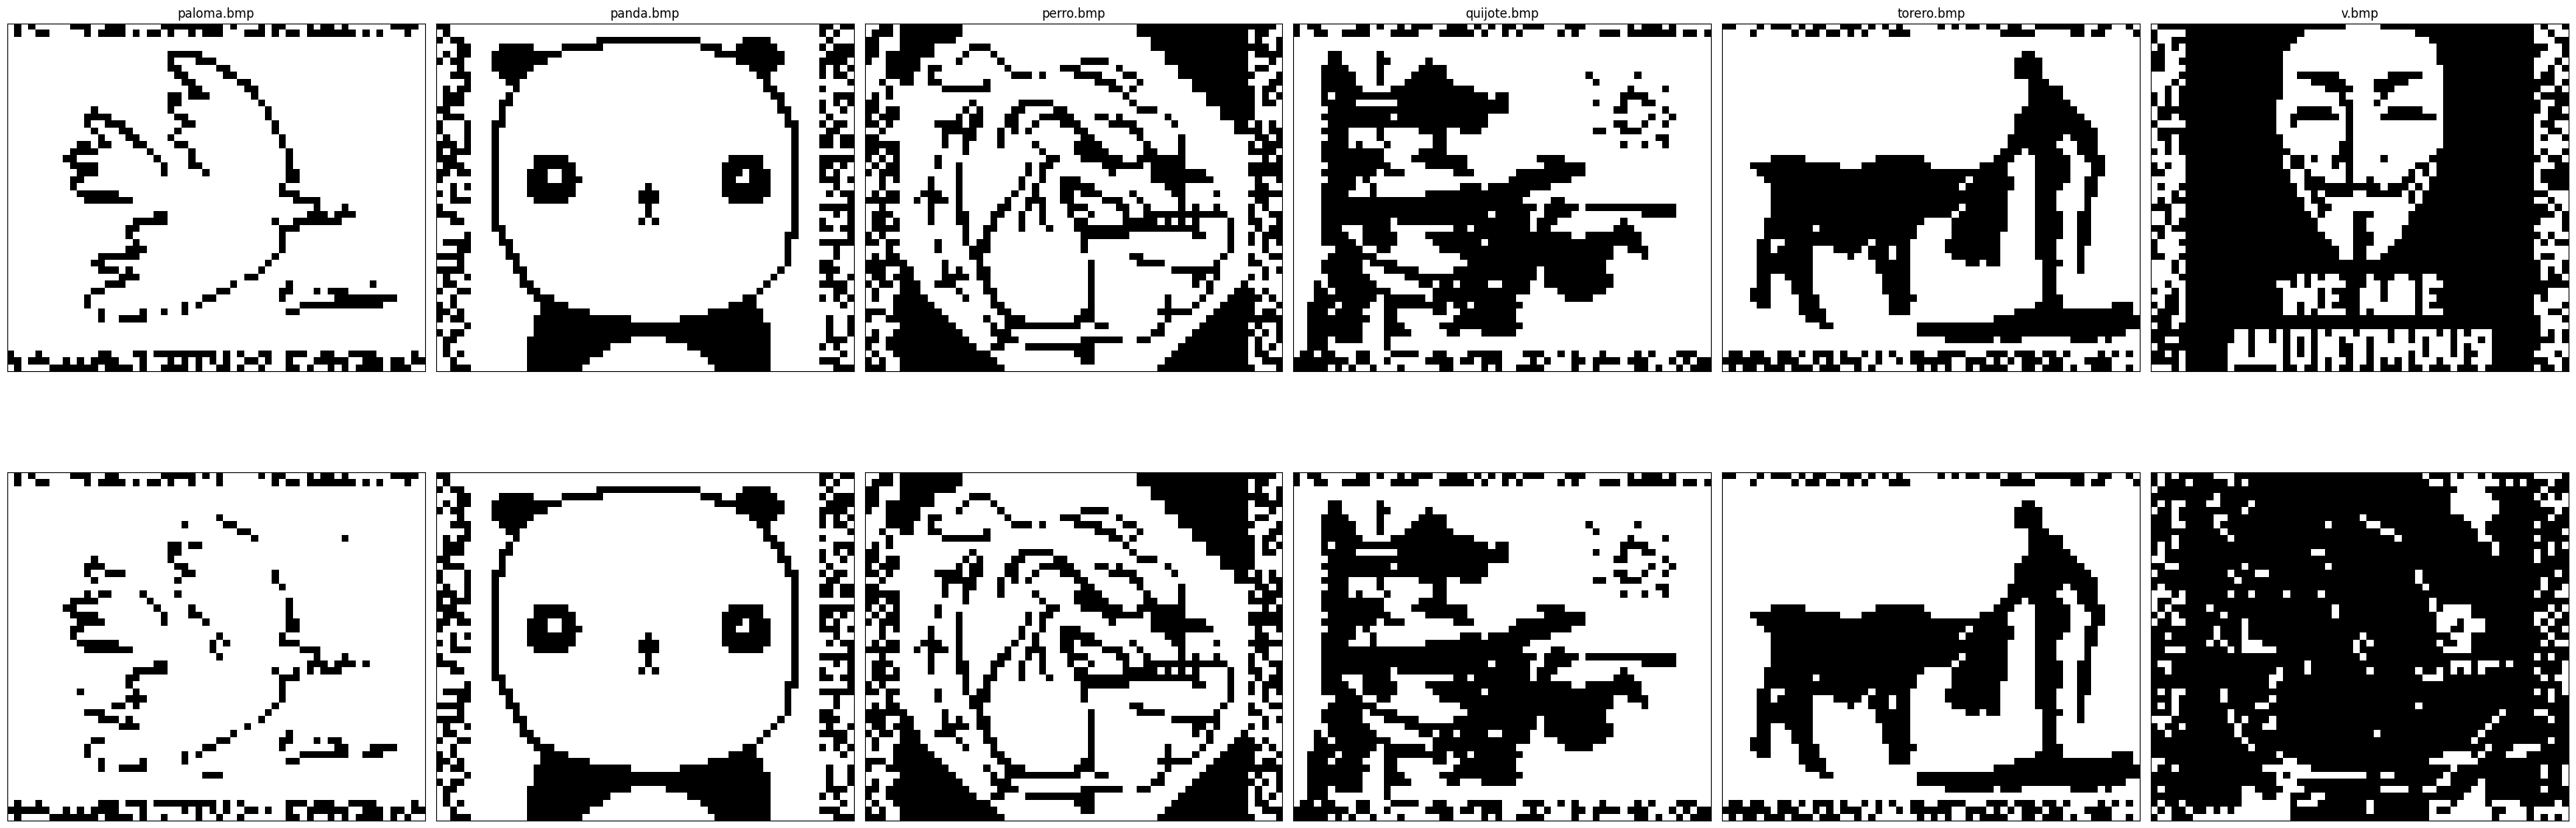

test finished after 2 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations
test finished after 1 iterations


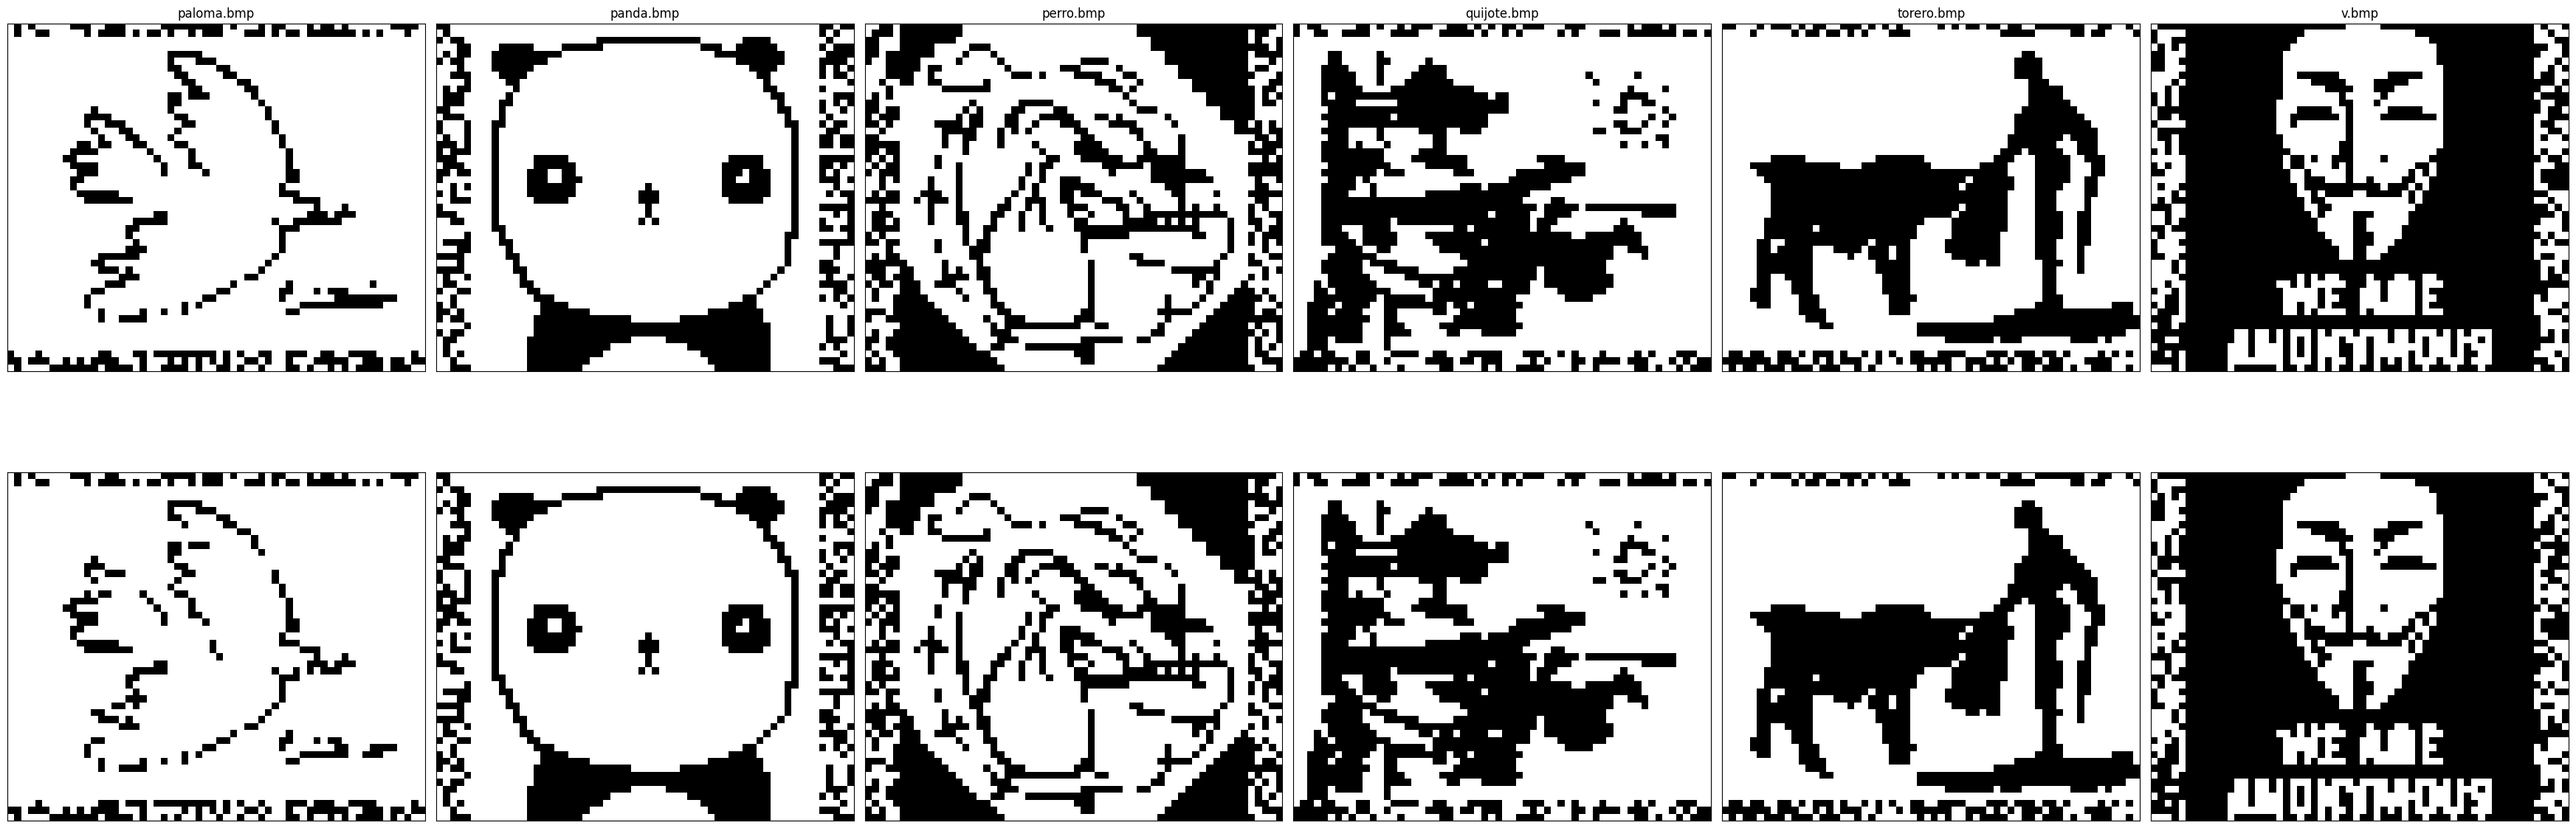

In [ ]:
dataset_train, width_max,height_max = create_dataset_from_images(images, "noise")

for j in range(len(dataset_train)):

  # Train the Hopfield network
  W = train_hopfield(dataset_train[:j+1], width_max, height_max)

  fig, axes = plt.subplots(2, 6, figsize=(35, 15))

  i = 0
  for image in dataset_train:
      plt.imshow(W)
      axes[0, i].imshow(image, cmap='gray')
      axes[0, i].set_title(str(images[i]))
      axes[0, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

      Y = test_hopfield(W, image)
      img = Y.reshape((height_max, width_max))
      axes[1, i].imshow(img, cmap='gray')
      axes[1, i].tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

      i += 1

  plt.subplots_adjust(wspace=0.4, hspace=0.1)

  fig.tight_layout()

  plt.show()

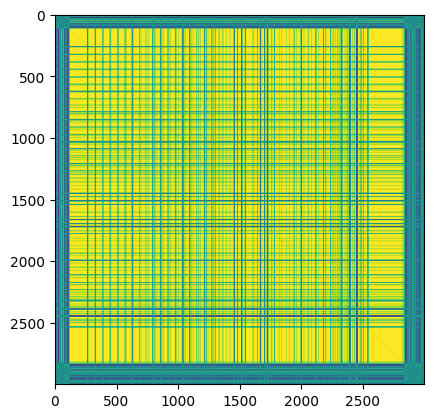

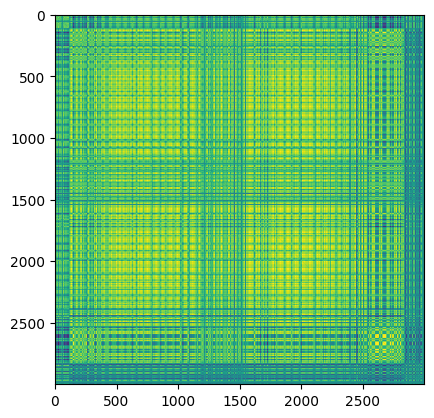

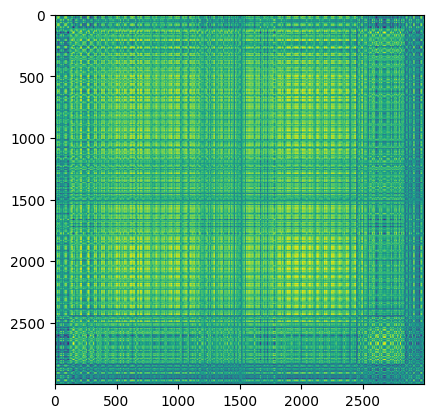

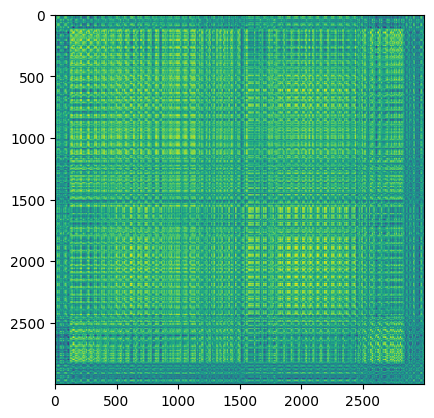

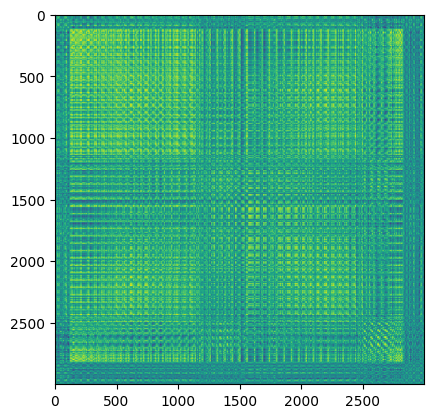

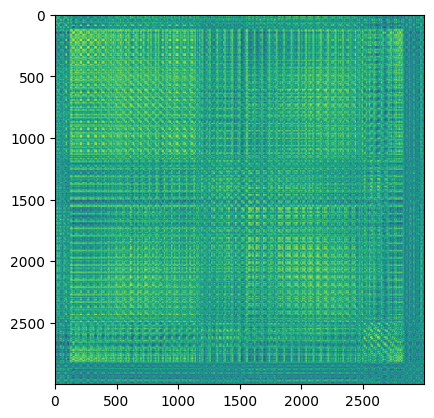

In [ ]:
for j in range(len(dataset_train)):  # The change of the matrix W with each image addition is shown here
  W = train_hopfield(dataset_train[:j+1], width_max, height_max)
  plt.imshow(W)
  plt.show()


# Ejercicio 2

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def train_hopfield(list_X, width_max, height_max): #Same training as before
    N = width_max * height_max
    W = np.zeros((N, N))
    eta = 0.5
    for X in list_X:
        X = np.array(X)
        X_flat = np.copy(X.flatten())
        Delta_W = eta * np.outer(X_flat, X_flat)
        np.fill_diagonal(Delta_W, 0)
        W += Delta_W
    return W

def generate_pattern(l):
    pattern = np.random.choice([-1, 1], size=l, p=[0.5, 0.5]) #generate a random pattern of -1 and 1 of length l
    return pattern

def compute_error(list_y, matrix_y_hat):
    N = len(list_y[0])
    M = len(list_y)
    matrix_y = np.array(list_y)

    bits_error = np.sum(np.abs(matrix_y - matrix_y_hat) / 2) #count the wrong bits
    error = bits_error / (N * M) #divide by the number of neurons times the number of patterns
    return error

def sincronic_predict(W, list_patterns):

    list_patterns_matrix = np.array(list_patterns)


    predict = np.matmul(list_patterns_matrix, W)


    predict = np.where(predict >= 0, 1, -1)

    return predict
def calculate_Pmax(N,p_error):

  width_patterns = 1
  len_patterns = N

  list_patterns = []
  P_max = 0
  error = 0

  while error < p_error:
      pattern = generate_pattern(len_patterns)
      list_patterns.append(pattern)

      W = train_hopfield(list_patterns, width_max=width_patterns, height_max=len_patterns)

      matrix_y_hat = sincronic_predict(W, list_patterns)

      error = compute_error(list_y=list_patterns, matrix_y_hat=matrix_y_hat)

      P_max += 1
  return P_max



In [ ]:
steps_N = range(1,100,1)
num_points = 100
p_error = 0.1
averaged_pmax_list = []
for N in steps_N:
  sum_pmax = 0
  for point in range(num_points):
    sum_pmax += calculate_Pmax(N,p_error)
  averaged_pmax = sum_pmax/num_points
  averaged_pmax_list.append(averaged_pmax)




In [ ]:
estimate_ratio = 0

for i in range(len(steps_N)):
  estimate_ratio += averaged_pmax_list[i]/steps_N[i]

print(estimate_ratio/len(steps_N))

0.6533261292296769


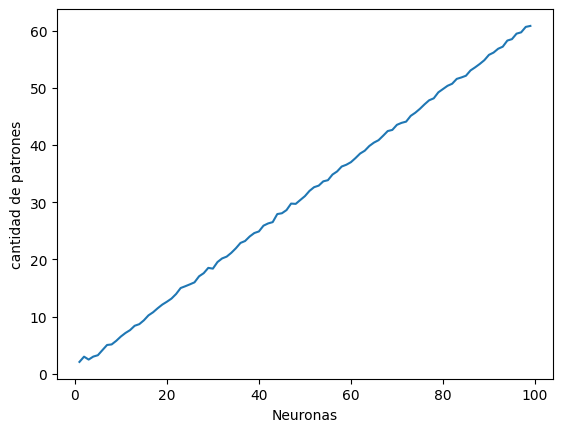

In [ ]:
plt.plot(steps_N,averaged_pmax_list)
plt.ylabel("cantidad de patrones")
plt.xlabel("Neuronas")
plt.show()

## Analysis of capacity for different errors allowed with 100 neurons and 1000 points

In [ ]:
list_p_error  = [0.001,0.0036,0.01,0.05, 0.1  ]
averaged_pmax_list2 = []
num_points = 1000
N =100
for p_error in list_p_error:

  sum_pmax = 0
  for point in range(num_points):
    sum_pmax += calculate_Pmax(N,p_error) #Obtener la cantidad maxima de patrones aprendidos
  averaged_pmax = sum_pmax/num_points # se promedian los puntos obtenidos para Pmax
  averaged_pmax_list2.append(averaged_pmax)

ratio_pmax_n = np.array(averaged_pmax_list2)/N
print(ratio_pmax_n)

[0.12198 0.15392 0.19535 0.37986 0.61692]


# Correlated Patterns


In [ ]:
def calculate_Pmax_corr(N,p_error, correlacion):

  width_patterns = 1
  len_patterns = N

  list_patterns = []
  P_max = 0
  error = 0
  max_iterations = 100
  while error < p_error and P_max<max_iterations:

      mu = np.zeros(len_patterns)
      sigma = np.full((len_patterns, len_patterns), correlacion)
      np.fill_diagonal(sigma, 1)

      pattern = np.random.multivariate_normal(mu, sigma)
      pattern = np.where(pattern >= 0, 1, -1)
      list_patterns.append(pattern)

      W = train_hopfield(list_patterns, width_max=width_patterns, height_max=len_patterns)

      matrix_y_hat = sincronic_predict(W, list_patterns)

      error = compute_error(list_y=list_patterns, matrix_y_hat=matrix_y_hat)

      P_max += 1
  return P_max



In [ ]:
# Parameters
len_pattern = 100
correlaciones = np.array(range(0,1000,10))/1000

tested_correlations = []
for correlacion in correlaciones:
  mu = np.zeros(len_pattern)
  sigma = np.full((len_pattern, len_pattern), correlacion)
  np.fill_diagonal(sigma, 1)

  patrones = []
  num_patrones = 100
  for i in range(num_patrones):
      pattern = np.random.multivariate_normal(mu, sigma)
      pattern = np.where(pattern >= 0, 1, -1)
      patrones.append(pattern)


  patrones_copy =  np.copy(patrones)

  total_correlation = 0
  num_correlations = 0

  while len(patrones_copy)>1:


    for i in range(1, len(patrones_copy)):

        if np.var(patrones[0]) < 1e-6 or np.var(patrones[i]) < 1e-6:
            total_correlation += 1
            num_correlations += 1
            continue

        correlation_matrix = np.corrcoef(patrones[0], patrones[i])
        correlation_value = correlation_matrix[0, 1]


        total_correlation += abs(correlation_value)
        num_correlations += 1
    patrones_copy= patrones_copy[1:]

  # Calculate average correlation (avoid division by zero)
  if num_correlations > 0:
      average_correlation = total_correlation / num_correlations
  else:
      average_correlation = 1

  tested_correlations.append(average_correlation)

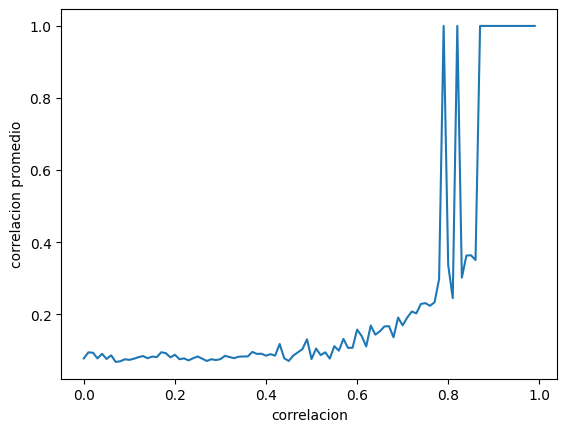

In [ ]:
plt.plot(correlaciones,tested_correlations)
plt.xlabel("correlacion")
plt.ylabel("correlacion promedio")
plt.show()

In [ ]:
import numpy as np

list_p_error  = [0.001,0.0036,0.01,0.05, 0.1  ]
correlaciones = np.array(range(0,1000,10))/1000

N=100
num_points = 10


p_errores_avg_pmax = []
for p_error in list_p_error:
  averaged_pmax_list = []
  for correlacion in correlaciones:
    sum_pmax = 0
    for point in range(num_points):
      sum_pmax += calculate_Pmax_corr(N,p_error,correlacion)  #Obtener la cantidad maxima de patrones aprendidos con los patrones correlacionados
    averaged_pmax = sum_pmax/num_points
    averaged_pmax_list.append(averaged_pmax)
  p_errores_avg_pmax.append(averaged_pmax_list)




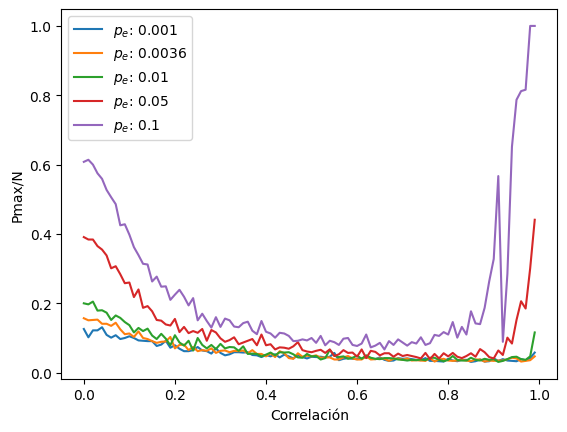

In [ ]:
ratios = np.array(p_errores_avg_pmax)/N

for i in range(len(list_p_error)):
  plt.plot(correlaciones,ratios[i], label=r"$p_e$: " +str(list_p_error[i]))
  plt.xlabel("Correlación")
  plt.ylabel("Pmax/N")
  plt.legend()
plt.show()